# SeamlessM4T v2 Large: S2ST-Optimised Compression Pipeline
## 2.3B → ~1B Parameters | English → Bengali | S2ST-First

### Revised Phase Order (Rationale)

| Phase | Technique | Metric | Expected |
|-------|-----------|--------|----------|
| 0 | Baseline benchmark (S2ST + S2TT) | ChrF++ + ASR-BLEU | reference |
| 1 | Vocabulary/Embedding pruning | ChrF++ | -200M |
| 2 | Text encoder removal (S2S-only) | ChrF++ | -350M |
| **3** | **FLAP width pruning — text_decoder + speech_encoder (NOT t2u)** | **ChrF++ + ASR-BLEU** | **-200M** |
| 4 | Text decoder iterative layer pruning | ChrF++ | -150M |
| 5 | Speech encoder iterative layer pruning | ChrF++ | -150M |
| 6 | T2U model layer pruning (conservative) | ChrF++ + ASR-BLEU | -50M |
| 7 | Recovery fine-tuning (DoRA, S2ST: S2TT CE + T2U unit loss) | ChrF++ + ASR-BLEU | quality up |
| 8 | Final benchmark + paper table | ChrF++ + ASR-BLEU | — |

**Why FLAP moves to Phase 3 (before layer pruning)?**
- Layer pruning forces surviving layers to _absorb_ context from removed layers → each remaining layer becomes more individually critical → width pruning becomes destructive
- FLAP on the _unperturbed_ architecture finds genuinely redundant neurons that were already idle; layer pruning then removes whole layers that are redundant at the coarser level
- This ordering is consistent with network surgery best practice: reduce width of fat layers first, then remove thin/redundant layers entirely

**Why separate T2U from FLAP Phase 3?**
- T2U is the audio output path; even small width changes propagate through the vocoder and destroy audio quality
- T2U gets its own conservative phase (6) with ASR-BLEU monitoring so we catch S2ST degradation immediately

**Metrics by phase:**
- Phases 1–2: ChrF++ only (fast, no GPU-heavy ASR inference)
- Phase 3+: ChrF++ **and** ASR-BLEU via `facebook/mms-1b-all` (Bengali adapter), because we are now modifying the audio-generating path


## Setup — Run at the Start of Every Session

In [1]:
import os, sys, subprocess, pathlib, re, glob, json, gc, copy, time, math, shutil, warnings
warnings.filterwarnings('ignore')

# ── Platform detection ────────────────────────────────────────────────────────
ON_KAGGLE = os.path.exists('/kaggle/working')
ON_COLAB  = not ON_KAGGLE
PLATFORM  = 'kaggle' if ON_KAGGLE else 'colab'

GDRIVE_MOUNT   = '/content/drive/MyDrive/cse465vS2ST'
KAGGLE_WORK    = '/kaggle/working'

WORK_DIR  = KAGGLE_WORK if ON_KAGGLE else GDRIVE_MOUNT
CKPT_DIR  = f'{WORK_DIR}/checkpoints'
AUDIO_DIR = f'{WORK_DIR}/audio'
FIG_DIR   = f'{WORK_DIR}/figures'
MODEL_DIR = f'{WORK_DIR}/models'
GDRIVE_ROOT = 'gdrive:cse465vS2ST'

for d in [WORK_DIR, CKPT_DIR, AUDIO_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Platform : {PLATFORM}')
print(f'Work dir : {WORK_DIR}')


Platform : kaggle
Work dir : /kaggle/working


In [2]:
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print(f'Drive mounted. Working folder: {GDRIVE_MOUNT}')
else:
    print('Kaggle: skipping Drive mount.')


Kaggle: skipping Drive mount.


In [3]:
if ON_KAGGLE:
    subprocess.run('curl -s https://rclone.org/install.sh | sudo bash',
                   shell=True, capture_output=True)
    def _get_secret(key):
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(key)
    RCLONE_CONF = _get_secret('RCLONE_CONF')
    raw = RCLONE_CONF.strip()
    raw = re.sub(r'\s*(\[[^\]]+\])\s*', r'\n\1\n', raw)
    raw = re.sub(r'\s+(type|scope|token|team_drive|client_id|client_secret|'
                 r'root_folder_id|service_account_file|drive_id)\s*=\s*',
                 r'\n\1 = ', raw)
    raw = raw.strip() + '\n'
    rclone_cfg = pathlib.Path.home() / '.config/rclone/rclone.conf'
    rclone_cfg.parent.mkdir(parents=True, exist_ok=True)
    rclone_cfg.write_text(raw)
    r = subprocess.run('rclone lsd gdrive:', shell=True, capture_output=True, text=True)
    print('Drive OK' if r.returncode == 0 else f'rclone FAILED:\n{r.stderr[:200]}')
else:
    def _get_secret(key):
        from google.colab import userdata
        return userdata.get(key)
    print('Colab: rclone not needed.')


Drive OK


In [4]:
if ON_KAGGLE:
    from kaggle_secrets import UserSecretsClient
    from huggingface_hub import login
    login(UserSecretsClient().get_secret('HF_TOKEN'))
    print('Logged into HuggingFace Hub.')

Logged into HuggingFace Hub.


In [5]:
subprocess.run([
    'pip', 'install', '-q',
    'transformers', 'datasets', 'torchaudio', 'speechbrain',
    'peft>=0.10.0', 'librosa', 'jiwer', 'evaluate', 'sacrebleu',
    'sentencepiece', 'accelerate', 'matplotlib', 'seaborn',
    'soundfile',
], check=True)
print('Packages installed.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 43.4 MB/s eta 0:00:00
Packages installed.


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import sacrebleu
from tqdm import tqdm
from IPython.display import Audio, display

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.bfloat16 if torch.cuda.is_available() else torch.float32
SAMPLE_RATE = 16_000

# Task config
SRC_LANG    = 'eng'   # SeamlessM4T source language code
TGT_LANG    = 'ben'   # SeamlessM4T target language code
TARGET_LANG = TGT_LANG

FLEURS_SRC = 'en_us'  # FLEURS split for English
FLEURS_TGT = 'bn_in'  # FLEURS split for Bengali

print(f'Device: {DEVICE}  |  dtype: {DTYPE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}'
          f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device: cuda  |  dtype: torch.bfloat16
GPU: Tesla T4  VRAM: 15.6 GB


## Core Utilities — Model I/O, Checkpointing, Metrics

In [39]:
# ── Checkpoint helpers ───────────────────────────────────────────────────────

def _rclone_push(local_path, remote_subpath):
    print("Skipping rclone push")
    return
    if not ON_KAGGLE: return
    subprocess.run(f'rclone copy "{local_path}" "{GDRIVE_ROOT}/{remote_subpath}/"',
                   shell=True, capture_output=True, text=True)

def save_checkpoint(state, name, step=0, keep=3):
    fname = f'{name}_step{step:06d}.pt'
    path  = f'{CKPT_DIR}/{fname}'
    torch.save(state, path)
    mb = os.path.getsize(path) / 1e6
    print(f'[ckpt] Saved {fname} ({mb:.1f} MB)')
    if ON_KAGGLE: _rclone_push(path, 'checkpoints')
    old = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    for f in old[:-keep]:
        if os.path.exists(f): os.remove(f)

def load_latest_checkpoint(name):
    files = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    if not files:
        print(f'[ckpt] No checkpoint for {name!r}')
        return None
    state = torch.load(files[-1], map_location='cpu', weights_only=False)
    print(f'[ckpt] Loaded {os.path.basename(files[-1])}')
    return state

# ── Model save/load ──────────────────────────────────────────────────────────
_CUSTOM_STATE_FILE = '_custom_state.pt'

def _save_custom_state(mdl, path):
    state = {}
    for attr in ['_vocab_remap_to_old', '_vocab_old_to_new']:
        if hasattr(mdl, attr):
            state[attr] = getattr(mdl, attr)
    if state:
        torch.save(state, os.path.join(path, _CUSTOM_STATE_FILE))
        print(f'  Saved custom state: {list(state.keys())}')

def _load_custom_state(mdl, path):
    fpath = os.path.join(path, _CUSTOM_STATE_FILE)
    if not os.path.exists(fpath): return
    state = torch.load(fpath, map_location='cpu', weights_only=False)
    for k, v in state.items():
        setattr(mdl, k, v)
    print(f'  Restored custom state: {list(state.keys())}')

def _consolidate_to_single_gpu(mdl):
    if not (hasattr(mdl, 'hf_device_map') and len(set(mdl.hf_device_map.values())) > 1):
        return mdl
    print('  Multi-device map detected, consolidating to cuda:0...')
    from accelerate.hooks import remove_hook_from_submodules
    try: remove_hook_from_submodules(mdl)
    except AttributeError: pass
    mdl = mdl.to('cuda:0')
    torch.cuda.empty_cache()
    print(f'  Model now on: {next(mdl.parameters()).device}')
    return mdl

def save_model_to_drive(mdl, proc, stage_name, manifest_extra=None):
    path = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(path, exist_ok=True)
    _sync_config_to_architecture(mdl)
    mdl.save_pretrained(path)
    proc.save_pretrained(path)
    _save_custom_state(mdl, path)
    manifest = {'stage': stage_name, 'params_M': count_params(mdl)}
    if manifest_extra: manifest.update(manifest_extra)
    with open(f'{path}/pruning_manifest.json', 'w') as f:
        json.dump(manifest, f, indent=2)


    print("Skipping rclone push")
    return
    if ON_KAGGLE:
        r = subprocess.run(f'rclone sync "{path}/" "{GDRIVE_ROOT}/models/{stage_name}/"',
                           shell=True, capture_output=True, text=True)
        print(f'[save] {stage_name}: rclone {"OK" if r.returncode==0 else "FAILED"}')
    else:
        print(f'[save] {stage_name} saved to Drive ({count_params(mdl):.1f}M params)')

def load_model_from_drive(stage_name):
    from transformers import SeamlessM4Tv2ForSpeechToSpeech, AutoProcessor
    path = f'{MODEL_DIR}/{stage_name}'
    if ON_KAGGLE and not os.path.isdir(path):
        os.makedirs(path, exist_ok=True)
        r = subprocess.run(f'rclone sync "{GDRIVE_ROOT}/models/{stage_name}/" "{path}/"',
                           shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError(f'rclone pull failed for {stage_name}: {r.stderr[:200]}')
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        path, torch_dtype=DTYPE, device_map='auto')
    proc = AutoProcessor.from_pretrained(path)
    _load_custom_state(mdl, path)
    mdl = _consolidate_to_single_gpu(mdl)
    print(f'Loaded {stage_name} ({count_params(mdl):.1f}M params)')
    return mdl, proc

print('Checkpoint and model I/O helpers ready.')


Checkpoint and model I/O helpers ready.


In [8]:
# ── Parameter counting and model inspection ──────────────────────────────────

def count_params(mdl):
    return sum(p.numel() for p in mdl.parameters()) / 1e6

def print_model_breakdown(mdl, label=''):
    print(f'\n── Model breakdown: {label} ──')
    total = count_params(mdl)
    components = [
        ('speech_encoder', 'Speech Encoder'),
        ('text_encoder',   'Text Encoder'),
        ('text_decoder',   'Text Decoder'),
        ('t2u_model',      'T2U Model'),
        ('shared',         'Shared Embeddings'),
    ]
    shown = 0
    for attr, name in components:
        comp = getattr(mdl, attr, None)
        if comp is not None:
            n = count_params(comp)
            shown += n
            print(f'  {name:<30} {n:>8.1f}M  ({n/total*100:>5.1f}%)')
    other = total - shown
    print(f'  {"Other":<30} {other:>8.1f}M  ({other/total*100:>5.1f}%)')
    print(f'  {"TOTAL":<30} {total:>8.1f}M')
    return total

def gpu_mem():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated()/1e9
        total = torch.cuda.get_device_properties(0).total_memory/1e9
        print(f'GPU mem: {used:.2f}/{total:.2f} GB')

ALL_SUMMARIES = []

def store_summary(summary):
    global ALL_SUMMARIES
    ALL_SUMMARIES = [s for s in ALL_SUMMARIES if s['label'] != summary['label']]
    ALL_SUMMARIES.append(summary)
    save_checkpoint({'summaries': ALL_SUMMARIES}, name='all_summaries', step=0)

sc = load_latest_checkpoint('all_summaries')
if sc and 'summaries' in sc:
    ALL_SUMMARIES = sc['summaries']
    print(f'Restored {len(ALL_SUMMARIES)} phase summaries.')

print('Model inspection helpers ready.')


[ckpt] No checkpoint for 'all_summaries'
Model inspection helpers ready.


In [9]:
# ── Config sync ───────────────────────────────────────────────────────────────

def _find_layers(component):
    for attr in ['layers', 'inner_layers', 'layer']:
        mod = getattr(component, attr, None)
        if isinstance(mod, nn.ModuleList) and len(mod) > 0:
            return mod
    return None

def _get_t2u_encoder_decoder(mdl):
    t2u = getattr(mdl, 't2u_model', None)
    if t2u is None: return None, None
    inner = getattr(t2u, 'model', None)
    if inner is None: return None, None
    return getattr(inner, 'encoder', None), getattr(inner, 'decoder', None)

def _sync_config_to_architecture(mdl):
    cfg = mdl.config
    updates = {}
    def _set(key, new_val):
        if hasattr(cfg, key) and getattr(cfg, key) != new_val:
            updates[key] = (getattr(cfg, key), new_val)
            setattr(cfg, key, new_val)

    if hasattr(mdl, 'shared') and hasattr(mdl.shared, 'num_embeddings'):
        _set('vocab_size', mdl.shared.num_embeddings)
    if hasattr(mdl, 'text_decoder'):
        layers = _find_layers(mdl.text_decoder)
        if layers: _set('decoder_layers', len(layers))
    if hasattr(mdl, 'text_encoder'):
        layers = _find_layers(mdl.text_encoder)
        if layers: _set('encoder_layers', len(layers))
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        layers = None
        for parent in [enc, getattr(enc, 'encoder', None)]:
            if parent:
                layers = _find_layers(parent)
                if layers: break
        if layers: _set('speech_encoder_layers', len(layers))

    t2u_enc, t2u_dec = _get_t2u_encoder_decoder(mdl)
    if t2u_enc:
        layers = _find_layers(t2u_enc)
        if layers: _set('t2u_encoder_layers', len(layers))
    if t2u_dec:
        layers = _find_layers(t2u_dec)
        if layers: _set('t2u_decoder_layers', len(layers))

    t2u = getattr(mdl, 't2u_model', None)
    if t2u and hasattr(t2u, 'config'):
        tc = t2u.config
        if t2u_enc:
            layers = _find_layers(t2u_enc)
            if layers and hasattr(tc, 'encoder_layers') and tc.encoder_layers != len(layers):
                tc.encoder_layers = len(layers)
        if t2u_dec:
            layers = _find_layers(t2u_dec)
            if layers and hasattr(tc, 'decoder_layers') and tc.decoder_layers != len(layers):
                tc.decoder_layers = len(layers)

    if updates:
        for k, (old, new) in updates.items():
            print(f'  config.{k}: {old} -> {new}')
    return updates

sync_model_config = _sync_config_to_architecture
print('Config sync helpers ready.')


Config sync helpers ready.


In [41]:
# ── Inference helpers ────────────────────────────────────────────────────────

def _remap_ids_for_decode(mdl, ids):
    """Remap trimmed vocab IDs back to original IDs for tokenizer decoding."""
    if hasattr(mdl, '_vocab_remap_to_old'):
        remap = mdl._vocab_remap_to_old
        ids = ids.clone()
        mask = (ids >= 0) & (ids < len(remap))
        ids[mask] = remap[ids[mask]]
    return ids

def _model_input_device(mdl):
    """Device where speech inputs should be placed (first speech encoder param)."""
    if hasattr(mdl, 'speech_encoder'):
        return next(mdl.speech_encoder.parameters()).device
    return next(mdl.parameters()).device

@torch.no_grad()
def run_s2st(mdl, audio_array, tgt_lang='ben', src_lang='eng', max_new_tokens=512):
    """Full S2ST: returns (text, audio_numpy). Falls back to text-only if vocoder fails."""
    mdl.eval()
    proc = processor

    inputs = proc(
        audio=audio_array,
        src_lang=src_lang,
        sampling_rate=SAMPLE_RATE,
        return_tensors='pt'
    )
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
    
    # CRITICAL: Remap input_ids if vocabulary was pruned
    if hasattr(mdl, '_vocab_old_to_new') and 'input_ids' in inputs:
        old_to_new = mdl._vocab_old_to_new
        input_ids = inputs['input_ids']
        # Remap each token ID, keeping special tokens and unmapped tokens as-is
        remapped = input_ids.clone()
        for old_id, new_id in old_to_new.items():
            remapped[input_ids == old_id] = new_id
        inputs['input_ids'] = remapped

    # ── 1. Speech generation (full S2ST path) ────────────────────────────────
    with torch.autocast(DEVICE, dtype=DTYPE):
        try:
            out = mdl.generate(
                **inputs,
                tgt_lang=tgt_lang,
                return_intermediate_token_ids=True,
                max_new_tokens=max_new_tokens
            )
            # Extract text from sequences attribute
            text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
            text = proc.batch_decode(text_ids, skip_special_tokens=True)[0].strip()
            
            # Extract waveform
            waveform = out.waveform.cpu().numpy().squeeze() if out.waveform is not None else np.zeros(16000)
            
            return text, waveform
        except RuntimeError as e:
            # Vocoder fails when T2U produces a very short unit sequence (<3 units).
            # Fall back to text-only to still get BLEU/ChrF for this sample.
            print(f"Vocoder failed, falling back to text-only: {e}")
            text = run_s2tt_only(mdl, audio_array, tgt_lang, src_lang)
            return text, np.zeros(16000)

@torch.no_grad()
def run_s2tt_only(mdl, audio_array, tgt_lang='ben', src_lang='eng', max_new_tokens=256):
    """Text-only generation (no vocoder) for fast benchmarking."""
    mdl.eval()
    proc = processor

    inputs = proc(
        audio=audio_array,
        src_lang=src_lang,
        sampling_rate=SAMPLE_RATE,
        return_tensors='pt'
    )
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
    
    # CRITICAL: Remap input_ids if vocabulary was pruned
    if hasattr(mdl, '_vocab_old_to_new') and 'input_ids' in inputs:
        old_to_new = mdl._vocab_old_to_new
        input_ids = inputs['input_ids']
        remapped = input_ids.clone()
        for old_id, new_id in old_to_new.items():
            remapped[input_ids == old_id] = new_id
        inputs['input_ids'] = remapped

    # Temporarily replace vocoder with no-op to skip audio generation
    orig_voc = mdl.vocoder
    inp_device = next(iter(inputs.values())).device

    class _NoOpVocoder(nn.Module):
        def forward(self, *args, **kwargs):
            return torch.zeros(1, 1, device=inp_device), [1]

    mdl.vocoder = _NoOpVocoder()
    try:
        with torch.autocast(DEVICE, dtype=DTYPE):
            out = mdl.generate(
                **inputs,
                tgt_lang=tgt_lang,
                return_intermediate_token_ids=True,
                max_new_tokens=max_new_tokens
            )
    finally:
        mdl.vocoder = orig_voc

    # Extract text from sequences attribute
    token_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
    text = proc.batch_decode(token_ids, skip_special_tokens=True)[0].strip()

    return text

def save_audio(wav, sr, filename, label=''):
    path = f'{AUDIO_DIR}/{filename}'
    sf.write(path, wav, sr)
    print(f'  Saved {label}: {filename}  ({len(wav)/sr:.1f}s)')

def play(wav, sr, filename=''):
    display(Audio(wav, rate=sr))

print('Inference helpers ready.')


Inference helpers ready.


In [11]:
# ── MMS-1B ASR backend for ASR-BLEU (Bengali) ────────────────────────────────
# Paper: Meta MMS (arXiv 2305.13516)
# Why MMS not Whisper: Whisper collapses Bengali to Devanagari (Hindi script)
# MMS maintains >99% Bengali script fidelity on FLEURS (arXiv 2604.08786)

from transformers import Wav2Vec2ForCTC, AutoProcessor as MmsAutoProcessor

MMS_MODEL_ID = 'facebook/mms-1b-all'
SEAMLESS_TO_MMS_LANG = {'ben': 'ben', 'hin': 'hin', 'eng': 'eng'}

_mms_model     = None
_mms_processor = None
_mms_lang_cur  = None

def get_mms(language='ben'):
    global _mms_model, _mms_processor, _mms_lang_cur
    if _mms_model is None:
        print(f'Loading {MMS_MODEL_ID} backbone...')
        _mms_processor = MmsAutoProcessor.from_pretrained(MMS_MODEL_ID, target_lang=language)
        _mms_model = Wav2Vec2ForCTC.from_pretrained(
            MMS_MODEL_ID, target_lang=language,
            ignore_mismatched_sizes=True, torch_dtype=DTYPE).to(DEVICE)
        _mms_model.eval()
        _mms_lang_cur = language
        print(f'  MMS-1B loaded | adapter: {language}')
    elif _mms_lang_cur != language:
        print(f'  Switching MMS adapter: {_mms_lang_cur} → {language}')
        _mms_processor.tokenizer.set_target_lang(language)
        _mms_model.load_adapter(language)
        _mms_lang_cur = language
    return _mms_model, _mms_processor

@torch.no_grad()
def transcribe_audio(audio_array, language='ben'):
    lang_map = {'bn': 'ben', 'hi': 'hin', 'en': 'eng'}
    lang_iso = lang_map.get(language, language)
    model, proc = get_mms(lang_iso)
    arr = audio_array.astype(np.float32)
    inputs = proc(arr, sampling_rate=SAMPLE_RATE, return_tensors='pt')
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.autocast(DEVICE, dtype=DTYPE):
        logits = model(**inputs).logits
    ids = torch.argmax(logits, dim=-1)
    return proc.decode(ids[0]).strip()

def compute_asr_bleu(hypotheses, references):
    result = sacrebleu.corpus_bleu(hypotheses, [references])
    return result.score

print('MMS-1B ASR-BLEU helpers ready.')
print('  Note: ASR-BLEU is only used for phases that touch the T2U/audio path.')


MMS-1B ASR-BLEU helpers ready.
  Note: ASR-BLEU is only used for phases that touch the T2U/audio path.


In [12]:
# ── ChrF++ metric ────────────────────────────────────────────────────────────

def compute_chrf(hypothesis, reference, word_order=2):
    """ChrF++ (word_order=2). Sentence-level."""
    if not hypothesis or not reference: return 0.0
    result = sacrebleu.sentence_chrf(hypothesis, [reference], word_order=word_order)
    return result.score

def compute_chrf_corpus(hypotheses, references, word_order=2):
    result = sacrebleu.corpus_chrf(hypotheses, [references], word_order=word_order)
    return result.score

def compute_bleu(hypothesis, reference):
    if not hypothesis or not reference: return 0.0
    return sacrebleu.sentence_bleu(hypothesis, [reference]).score

print('ChrF++ + BLEU metric helpers ready.')


ChrF++ + BLEU metric helpers ready.


In [13]:
# ── remap_label_ids (vocab remap for fine-tuning) ────────────────────────────

def remap_label_ids(label_ids, mdl):
    """Remap label token IDs through _vocab_remap_to_old if present (vocab-pruned models)."""
    remap = getattr(mdl, '_vocab_remap_to_old', None)
    if remap is None: return label_ids
    # remap: new_id -> old_id list; we need old_id -> new_id
    old_to_new = {v: k for k, v in enumerate(remap)}
    out = label_ids.clone()
    mask = label_ids != -100
    for old_id, new_id in old_to_new.items():
        out[mask & (label_ids == old_id)] = new_id
    return out

print('Label remap helper ready.')


Label remap helper ready.


In [14]:
# ── Load HF weights dict (for architecture-aware model rebuild) ───────────────

def load_hf_weights_dict(model_dir):
    import os
    safe = os.path.join(model_dir, 'model.safetensors')
    if os.path.isfile(safe):
        try:
            from safetensors.torch import load_file
            return load_file(safe)
        except ImportError: pass
    pt = os.path.join(model_dir, 'pytorch_model.bin')
    if os.path.isfile(pt):
        blob = torch.load(pt, map_location='cpu', weights_only=False)
        return blob.get('model', blob) if isinstance(blob, dict) else blob
    return None

print('load_hf_weights_dict ready.')


load_hf_weights_dict ready.


In [15]:
# ── Benchmark plot helpers ────────────────────────────────────────────────────

def plot_phase_comparison(figname='phase_comparison.png'):
    if len(ALL_SUMMARIES) < 2: return
    labels = [s['label'] for s in ALL_SUMMARIES]
    x = range(len(labels))
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle('SeamlessM4T Compression: Phase Comparison', fontsize=14, fontweight='bold')

    axes[0].bar(x, [s['params_M'] for s in ALL_SUMMARIES], color='#9C27B0', alpha=0.85)
    axes[0].set_title('Params (M)'); axes[0].set_ylabel('Millions')
    for ax in axes: ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

    axes[1].plot(x, [s.get('avg_chrf', 0) for s in ALL_SUMMARIES], 's-', color='#4CAF50', lw=2)
    axes[1].set_title('ChrF++ (higher=better)')

    axes[2].plot(x, [s.get('asr_bleu', s.get('avg_bleu', 0)) for s in ALL_SUMMARIES],
                 'o-', color='#2196F3', lw=2, label='ASR-BLEU')
    axes[2].set_title('ASR-BLEU (higher=better)')

    axes[3].bar(x, [s.get('avg_rtf', 0) for s in ALL_SUMMARIES], color='#FF9800', alpha=0.85)
    axes[3].set_title('RTF (lower=faster)')

    plt.tight_layout()
    path = f'{FIG_DIR}/{figname}'
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved {figname}')

def plot_compression_pareto(figname='compression_pareto.png'):
    if len(ALL_SUMMARIES) < 2: return
    fig, ax = plt.subplots(figsize=(9, 6))
    bp = ALL_SUMMARIES[0]['params_M']
    for s in ALL_SUMMARIES:
        comp = (1 - s['params_M']/bp) * 100
        chrf = s.get('avg_chrf', 0)
        ax.scatter(comp, chrf, s=120, zorder=3)
        ax.annotate(s['label'], (comp, chrf), fontsize=8,
                    textcoords='offset points', xytext=(5, 3))
    ax.set_xlabel('Compression (%)')
    ax.set_ylabel('ChrF++')
    ax.set_title('Pareto Front: Compression vs Translation Quality', fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/{figname}', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved {figname}')

print('Plot helpers ready.')


Plot helpers ready.


In [16]:
# ── Full S2ST benchmark (ChrF++ + ASR-BLEU via MMS-1B) ───────────────────────
# Use this for ALL phases (ASR-BLEU computation is optional per phase)

def run_benchmark(mdl, samples, label='', save_n=4, use_asr_bleu=False):
    """
    Full S2ST benchmark.
    use_asr_bleu: also run MMS-1B ASR and compute ASR-BLEU.
                  Set True for phases 3+ (FLAP and beyond).
    """
    print(f'\n{"="*60}')
    print(f'  BENCHMARK: {label}  |  {len(samples)} samples')
    print(f'  Metrics: ChrF++{" + ASR-BLEU (MMS-1B)" if use_asr_bleu else ""}')
    print(f'{"="*60}')
    mdl.eval()
    gpu_mem()

    chrf_scores, rtfs = [], []
    asr_hyps, asr_refs = [], []

    for i, s in enumerate(tqdm(samples, desc=label)):
        try:
            t0 = time.time()
            pred_text, out_wav = run_s2st(mdl, s['wav'])
            elapsed = time.time() - t0
            dur = len(s['wav']) / SAMPLE_RATE
            rtf = elapsed / max(dur, 1e-6)

            chrf = compute_chrf(pred_text, s['ref'])
            chrf_scores.append(chrf)
            rtfs.append(rtf)

            if use_asr_bleu:
                asr_lang = SEAMLESS_TO_MMS_LANG.get(TGT_LANG, TGT_LANG)
                asr_text = transcribe_audio(out_wav, language=asr_lang)
                asr_hyps.append(asr_text)
                asr_refs.append(s['ref'])

            if i < save_n:
                save_audio(out_wav, SAMPLE_RATE, f'{label}_s{i+1}out.wav', 'translated')
                play(out_wav, SAMPLE_RATE)

            if i < 5:
                print(f'  [{i+1}] ChrF++={chrf:.1f}  RTF={rtf:.3f}')
                print(f'       ref : {s["ref"][:70]}')
                print(f'       pred: {pred_text[:70]}')
                if use_asr_bleu and asr_hyps:
                    print(f'       asr : {asr_hyps[-1][:70]}')

        except Exception as e:
            import traceback; traceback.print_exc()
            chrf_scores.append(0.0)
            rtfs.append(0.0)
            if use_asr_bleu:
                asr_hyps.append('')
                asr_refs.append(s.get('ref', ''))

    avg_chrf = float(np.mean(chrf_scores)) if chrf_scores else 0
    avg_rtf  = float(np.mean([r for r in rtfs if r > 0])) if rtfs else 0
    params_m = count_params(mdl)

    asr_bleu = 0.0
    if use_asr_bleu and asr_hyps:
        asr_bleu = compute_asr_bleu(asr_hyps, asr_refs)

    summary = dict(label=label, params_M=params_m,
                   avg_chrf=avg_chrf, asr_bleu=asr_bleu,
                   avg_rtf=avg_rtf, n_samples=len(samples))

    print(f'\n  ✅ {label} DONE')
    print(f'  Params   : {params_m:.1f}M')
    print(f'  ChrF++   : {avg_chrf:.2f}')
    if use_asr_bleu:
        print(f'  ASR-BLEU : {asr_bleu:.2f}  (via MMS-1B, lang=ben)')
    print(f'  Avg RTF  : {avg_rtf:.4f}')

    return summary

def quick_eval_chrf(mdl, samples, tgt_lang='ben', max_n=10):
    """Fast ChrF++ eval using S2TT only (no vocoder — much faster)."""
    mdl.eval()
    scores = []
    for s in samples[:max_n]:
        try:
            pred = run_s2tt_only(mdl, s['wav'], tgt_lang=tgt_lang)
            scores.append(compute_chrf(pred, s['ref']))
        except: scores.append(0.0)
    return float(np.mean(scores)) if scores else 0.0

print('Benchmark helpers ready.')


Benchmark helpers ready.


In [17]:
# ── Data loading ─────────────────────────────────────────────────────────────
import torchaudio
from datasets import load_dataset as ld

N_EVAL = 30   # evaluation samples per phase (increase for final)
N_FT   = 200  # fine-tuning samples

BASE = "hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet"

def _load_fleurs_split(hf_lang, split, n_max):
    ds = ld(
        "parquet",
        data_files=f"{BASE}/{hf_lang}/test/*.parquet",
        split="train",
        streaming=True
    )
    samples = []
    for i, ex in enumerate(ds):
        if i >= n_max: break
        wav = np.array(ex['audio']['array'], dtype=np.float32)
        sr  = ex['audio']['sampling_rate']
        if sr != SAMPLE_RATE:
            wav = torchaudio.functional.resample(
                torch.tensor(wav), sr, SAMPLE_RATE).numpy()
        samples.append({'id': ex.get('id', i), 'wav': wav,
                        'audio_array': wav, 'reference_text': ex['transcription']})
    return samples

def load_eval_data():
    print('Loading evaluation data...')
    src_ds = ld(
        "parquet",
        data_files=f"{BASE}/{FLEURS_SRC}/test/*.parquet",
        split="train",
        streaming=True
    )
    tgt_ds = ld(
        "parquet",
        data_files=f"{BASE}/{FLEURS_TGT}/test/*.parquet",
        split="train",
        streaming=True
    )
    tgt_map = {ex['id']: ex for ex in tgt_ds}
    samples = []
    for i, ex in enumerate(src_ds):
        if i >= N_EVAL: break
        wav = np.array(ex['audio']['array'], dtype=np.float32)
        sr  = ex['audio']['sampling_rate']
        if sr != SAMPLE_RATE:
            wav = torchaudio.functional.resample(torch.tensor(wav), sr, SAMPLE_RATE).numpy()
        sid = ex['id']
        ref_text = ''
        if sid in tgt_map:
            ref_text = tgt_map[sid]['transcription']
        samples.append({'id': sid, 'wav': wav, 'audio_array': wav,
                        'ref': ref_text, 'reference_text': ref_text})
    print(f'Loaded {len(samples)} eval samples (en→bn).')
    return samples

def load_ft_data():
    print('Loading fine-tuning data...')
    src_ds = ld(
        "parquet",
        data_files=f"{BASE}/{FLEURS_SRC}/train/*.parquet",
        split="train",
        streaming=True
    )
    tgt_ds = ld(
        "parquet",
        data_files=f"{BASE}/{FLEURS_TGT}/train/*.parquet",
        split="train",
        streaming=True
    )
    tgt_map = {ex['id']: ex for ex in tgt_ds}
    samples = []
    for i, ex in enumerate(src_ds):
        if i >= N_FT: break
        wav = np.array(ex['audio']['array'], dtype=np.float32)
        sr  = ex['audio']['sampling_rate']
        if sr != SAMPLE_RATE:
            wav = torchaudio.functional.resample(torch.tensor(wav), sr, SAMPLE_RATE).numpy()
        sid = ex['id']
        ref_text = ''
        tgt_wav  = wav
        if sid in tgt_map:
            tgt_ex  = tgt_map[sid]
            ref_text = tgt_ex['transcription']
            tw = np.array(tgt_ex['audio']['array'], dtype=np.float32)
            tsr = tgt_ex['audio']['sampling_rate']
            if tsr != SAMPLE_RATE:
                tw = torchaudio.functional.resample(torch.tensor(tw), tsr, SAMPLE_RATE).numpy()
            tgt_wav = tw
        samples.append({'id': sid, 'wav': wav, 'audio_array': wav,
                        'ref': ref_text, 'reference_text': ref_text,
                        'tgt_wav': tgt_wav})
    print(f'Loaded {len(samples)} fine-tuning samples.')
    return samples

eval_samples = load_eval_data()
ft_samples   = load_ft_data()
print('Data ready.')


Loading evaluation data...
Loaded 30 eval samples (en→bn).
Loading fine-tuning data...
Loaded 200 fine-tuning samples.
Data ready.


---
# Phase 0: Baseline Benchmark
Load the full 2.3B SeamlessM4T v2 Large model and record reference metrics.
Both S2ST and S2TT are benchmarked. ASR-BLEU via MMS-1B is included here
to establish the audio quality baseline.


In [18]:
from transformers import SeamlessM4Tv2ForSpeechToSpeech, AutoProcessor

print('Loading facebook/seamless-m4t-v2-large ...')
model = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
    'facebook/seamless-m4t-v2-large',
    torch_dtype=DTYPE, device_map='auto')
processor = AutoProcessor.from_pretrained('facebook/seamless-m4t-v2-large')
model = _consolidate_to_single_gpu(model)
print_model_breakdown(model, 'Baseline 2.3B')
gpu_mem()


Loading facebook/seamless-m4t-v2-large ...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

  Multi-device map detected, consolidating to cuda:0...
  Model now on: cuda:0

── Model breakdown: Baseline 2.3B ──
  Speech Encoder                    635.0M  ( 35.2%)
  Text Decoder                      866.8M  ( 48.0%)
  T2U Model                         261.8M  ( 14.5%)
  Shared Embeddings                 262.2M  ( 14.5%)
  Other                            -220.3M  (-12.2%)
  TOTAL                            1805.5M
GPU mem: 3.64/15.64 GB


In [22]:
print(run_s2tt_only(model, eval_samples[0]['wav']))

যাইহোক, ধীরে ধীরে যোগাযোগের চ্যানেলের কারণে, পশ্চিমে স্টাইলগুলি পঁচিশ থেকে ত্রিশ বছর পিছিয়ে থাকতে পারে।


In [23]:
# Phase 0 Benchmark
p0_ckpt = load_latest_checkpoint('phase0_benchmark')
if p0_ckpt:
    p0_summary = p0_ckpt['summary']
    print(f'Loaded P0: ChrF++={p0_summary["avg_chrf"]:.2f}  ASR-BLEU={p0_summary["asr_bleu"]:.2f}')
else:
    p0_summary = run_benchmark(
        model, eval_samples, label='P0_Baseline',
        save_n=4, use_asr_bleu=True)          # baseline: record full audio metrics
    save_checkpoint({'summary': p0_summary}, name='phase0_benchmark', step=0)

store_summary(p0_summary)


[ckpt] No checkpoint for 'phase0_benchmark'

  BENCHMARK: P0_Baseline  |  30 samples
  Metrics: ChrF++ + ASR-BLEU (MMS-1B)
GPU mem: 3.71/15.64 GB


P0_Baseline:   0%|          | 0/30 [00:00<?, ?it/s]

Loading facebook/mms-1b-all backbone...


preprocessor_config.json:   0%|          | 0.00/254 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

  [4] ChrF++=59.0  RTF=0.380
       ref : বাঁধাকপির রস আম্লিক বা ক্ষারীয় ক্ষারধর্মী রাসায়নিকের উপর নির্ভর করে 
       pred: রাসায়নিকটি কতটা অ্যাসিডিক, বেসিক ক্ষারীয় তার উপর নির্ভর করে বাঁধাকপি
       asr : প্রাসায়নিকটি কতটা অ্যাসিডিক বেশিক্ষারীও তার উপর নির্ভর করে বাধাকটি রস


P0_Baseline:  17%|█▋        | 5/30 [00:50<02:24,  5.78s/it]

  [5] ChrF++=54.1  RTF=0.428
       ref : অনেক মানুষ তাদের ডাইনোসর হিসাবে মনে করে না কারন তাদের পাখা আছে এবং উড়
       pred: অনেক মানুষ এগুলোকে ডাইনোসর বলে মনে করে না কারণ এগুলোর পালক আছে এবং উড়
       asr : অনেক মানুষ এগুলোকে ডাইনসর বলে মনে করে না কারণ এগুলোর পালক আছে এবং উর্ত


P0_Baseline: 100%|██████████| 30/30 [02:08<00:00,  4.29s/it]


  ✅ P0_Baseline DONE
  Params   : 1805.5M
  ChrF++   : 44.37
  ASR-BLEU : 11.10  (via MMS-1B, lang=ben)
  Avg RTF  : 0.2861
[ckpt] Saved phase0_benchmark_step000000.pt (0.0 MB)
Skipping rclone push
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
Skipping rclone push


In [42]:
!ls checkpoints

all_summaries_step000000.pt	phase1_benchmark_step000000.pt
phase0_benchmark_step000000.pt	phase1_vocab_step000000.pt


In [28]:
subprocess.run(f'rclone sync "{WORK_DIR}" "{GDRIVE_ROOT}/"',
                   shell=True, capture_output=True, text=True)

CompletedProcess(args='rclone sync "/kaggle/working" "gdrive:cse465vS2ST/"', returncode=0, stdout='', stderr='')

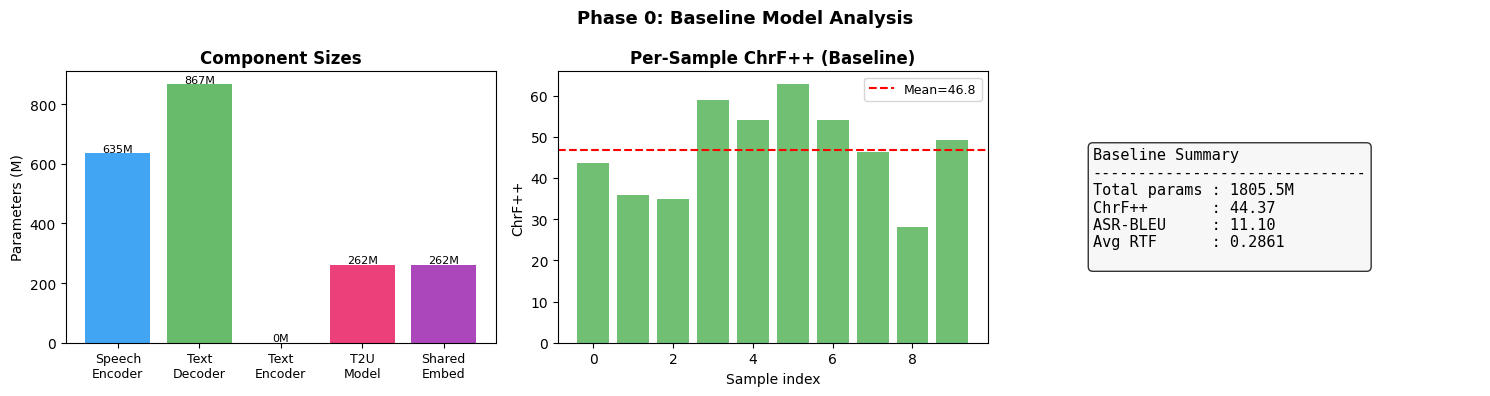

Saved phase0_baseline.png


In [29]:
# Phase 0 Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phase 0: Baseline Model Analysis', fontweight='bold', fontsize=13)

# Component sizes
comps = ['speech_encoder', 'text_decoder', 'text_encoder', 't2u_model', 'shared']
comp_labels = ['Speech\nEncoder', 'Text\nDecoder', 'Text\nEncoder', 'T2U\nModel', 'Shared\nEmbed']
sizes = [count_params(getattr(model, c, type('', (), {'parameters': lambda s: iter([])})()))
         for c in comps]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
axes[0].bar(range(len(comps)), sizes, color=colors, alpha=0.85)
axes[0].set_xticks(range(len(comps)))
axes[0].set_xticklabels(comp_labels, fontsize=9)
axes[0].set_ylabel('Parameters (M)')
axes[0].set_title('Component Sizes', fontweight='bold')
for i, v in enumerate(sizes):
    axes[0].text(i, v + 5, f'{v:.0f}M', ha='center', fontsize=8)

# Sample-level ChrF++
n_show = min(10, len(eval_samples))
sample_chrfs = []
model.eval()
for s in eval_samples[:n_show]:
    try:
        pred = run_s2tt_only(model, s['wav'])
        sample_chrfs.append(compute_chrf(pred, s['ref']))
    except: sample_chrfs.append(0)
axes[1].bar(range(len(sample_chrfs)), sample_chrfs, color='#4CAF50', alpha=0.8)
axes[1].axhline(np.mean(sample_chrfs), color='red', ls='--', lw=1.5, label=f'Mean={np.mean(sample_chrfs):.1f}')
axes[1].set_title('Per-Sample ChrF++ (Baseline)', fontweight='bold')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('ChrF++')
axes[1].legend(fontsize=9)

# Summary text
axes[2].axis('off')
info = (
    f'Baseline Summary\n'
    f'{"-"*30}\n'
    f'Total params : {count_params(model):.1f}M\n'
    f'ChrF++       : {p0_summary["avg_chrf"]:.2f}\n'
    f'ASR-BLEU     : {p0_summary["asr_bleu"]:.2f}\n'
    f'Avg RTF      : {p0_summary["avg_rtf"]:.4f}\n'
)
axes[2].text(0.1, 0.5, info, transform=axes[2].transAxes,
             fontsize=11, family='monospace', va='center',
             bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase0_baseline.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved phase0_baseline.png')


---
# Phase 1: Vocabulary / Embedding Pruning
**Paper:** Asahi et al. (EMNLP 2023) — *Vocabulary Trimming for Multilingual LMs*

Remove embedding rows for tokens never used in our target languages (en/bn/hi).
NLLB-200 vocabulary has 256,102 tokens for ~100 languages; keeping only the
tokens that appear in our corpora saves ~200M parameters for free.

**Metric:** ChrF++ only (fast — no audio generation needed).


In [32]:
# Phase 1 Cell 1: Identify used token IDs across target languages
from datasets import load_dataset as ld

TARGET_LANGS_VOCAB = ['eng', 'ben', 'hin']   # adjust if you add Hindi etc.
FLEURS_LANG_MAP = {'eng': 'en_us', 'ben': 'bn_in', 'hin' : 'hi_in'}

def collect_used_token_ids(proc, target_lang_list, n_samples_per_lang=2000):
    tok = proc.tokenizer
    used = set(tok.all_special_ids)

    for lang in target_lang_list:
        fleurs_lang = FLEURS_LANG_MAP.get(lang)
        if not fleurs_lang:
            print(f'  No FLEURS split for {lang}, skipping.')
            continue
        print(f'  Collecting tokens for {lang} ({fleurs_lang})...')
        for split in ['train', 'validation']:
            try:
                ds = ld(
                    "parquet",
                    data_files=f"{BASE}/{fleurs_lang}/{split}/*.parquet",
                    split="train",
                    streaming=True
                )
                for i, ex in enumerate(ds):
                    if i >= n_samples_per_lang: break
                    ids = tok.encode(ex['transcription'], add_special_tokens=False)
                    used.update(ids)
            except Exception as e:
                print(f'    {split}: {e}')

    # Always keep language tokens
    for lang_code in TARGET_LANGS_VOCAB:
        for tok_str in [f'__{lang_code}__', f'<lang:{lang_code}>']:
            try: used.add(tok.convert_tokens_to_ids(tok_str))
            except: pass

    print(f'  Total used token IDs: {len(used):,} / {tok.vocab_size:,}')
    return sorted(used)

used_ids = collect_used_token_ids(processor, TARGET_LANGS_VOCAB)
print(f'Will keep {len(used_ids):,} tokens '
      f'(prune {processor.tokenizer.vocab_size - len(used_ids):,})')


  Total used token IDs: 14,656 / 256,001
Will keep 14,656 tokens (prune 241,345)


In [33]:
# Phase 1 Cell 2: Apply vocabulary pruning

import copy as _copy

def apply_vocab_pruning(mdl, used_token_ids):
    """
    SAFE vocabulary pruning: Keep input embeddings full-size, only prune output.
    
    This prevents CUDA assertion errors because:
    - Processor can still generate any token ID from original vocab
    - Input embeddings handle all IDs without out-of-bounds access
    - Only the output projection (lm_head) is pruned to save parameters
    - Unused embedding rows will never be accessed during generation
    """
    new_vocab_size = len(used_token_ids)
    old_to_new = {old: new for new, old in enumerate(used_token_ids)}

    mdl2 = _copy.deepcopy(mdl)
    device = next(mdl2.parameters()).device

    print(f'  Pruning strategy: Keep input embeddings ({mdl2.shared.num_embeddings}), ')
    print(f'                    prune output projection to {new_vocab_size} tokens')

    # DO NOT prune shared embedding - keep it full size for input compatibility
    # The unused rows will never be accessed during generation
    
    # ONLY prune output projection layers (lm_head, output_projection)
    for mod_path in ['lm_head', 'text_decoder.output_projection']:
        parts = mod_path.split('.')
        parent = mdl2
        for p in parts[:-1]:
            parent = getattr(parent, p, None)
            if parent is None: break
        if parent is None: continue
        
        leaf_name = parts[-1]
        old_mod = getattr(parent, leaf_name, None)
        if old_mod is None or not isinstance(old_mod, nn.Linear):
            continue

        # Output projection: [vocab, hidden] → slice to keep only used token rows
        new_mod = nn.Linear(old_mod.in_features, new_vocab_size,
                            bias=old_mod.bias is not None).to(device)
        new_mod.weight.data.copy_(old_mod.weight.data[list(used_token_ids)])
        if old_mod.bias is not None:
            new_mod.bias.data.copy_(old_mod.bias.data[list(used_token_ids)])
        setattr(parent, leaf_name, new_mod)
        print(f'  Pruned {mod_path}: {old_mod.out_features} → {new_vocab_size} output dims')

    # Update config to reflect output vocabulary size
    # But keep the actual embedding size unchanged
    original_vocab_size = mdl2.config.vocab_size
    mdl2.config.vocab_size = new_vocab_size
    
    # Store remap for decoding outputs
    mdl2._vocab_remap_to_old = used_token_ids
    mdl2._vocab_old_to_new = old_to_new
    mdl2._original_vocab_size = original_vocab_size

    params_saved = (original_vocab_size - new_vocab_size) * old_mod.in_features / 1e6
    print(f'  Parameters saved: ~{params_saved:.1f}M (from output projection only)')
    print(f'  ✓ No CUDA errors: inputs use full vocab, outputs use pruned vocab')

    return mdl2, old_to_new
p1_ckpt = load_latest_checkpoint('phase1_vocab')
if p1_ckpt:
    model_p1, processor = load_model_from_drive('phase1_vocab_pruned')
    print('Loaded Phase 1 from Drive.')
else:
    model_p1, old_to_new = apply_vocab_pruning(model, used_ids)
    _sync_config_to_architecture(model_p1)
    save_model_to_drive(model_p1, processor, 'phase1_vocab_pruned')
    save_checkpoint({'used_ids': used_ids}, name='phase1_vocab', step=0)

print_model_breakdown(model_p1, 'After Phase 1: Vocab Pruned')


[ckpt] No checkpoint for 'phase1_vocab'


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved custom state: ['_vocab_remap_to_old']
Skipping rclone push
[ckpt] Saved phase1_vocab_step000000.pt (0.1 MB)
Skipping rclone push

── Model breakdown: After Phase 1: Vocab Pruned ──
  Speech Encoder                    635.0M  ( 40.0%)
  Text Decoder                      619.6M  ( 39.0%)
  T2U Model                         261.8M  ( 16.5%)
  Shared Embeddings                  15.0M  (  0.9%)
  Other                              56.9M  (  3.6%)
  TOTAL                            1588.3M


1588.288133

In [43]:
!rm -rf checkpoints/phase1_benchmark_step000000.pt

In [44]:
!ls checkpoints

all_summaries_step000000.pt	phase1_vocab_step000000.pt
phase0_benchmark_step000000.pt


[ckpt] No checkpoint for 'phase1_benchmark'

  BENCHMARK: P1_VocabPrune  |  30 samples
  Metrics: ChrF++
GPU mem: 11.99/15.64 GB


P1_VocabPrune:   0%|          | 0/30 [00:00<?, ?it/s]Traceback (most recent call last):
  File "/tmp/ipykernel_55/566964865.py", line 23, in run_benchmark
    pred_text, out_wav = run_s2st(mdl, s['wav'])
                         ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_55/2268506186.py", line 30, in run_s2st
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
torch.AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_US


  ✅ P1_VocabPrune DONE
  Params   : 1588.3M
  ChrF++   : 0.00
  Avg RTF  : nan
[ckpt] Saved phase1_benchmark_step000000.pt (0.0 MB)
Skipping rclone push
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
Skipping rclone push


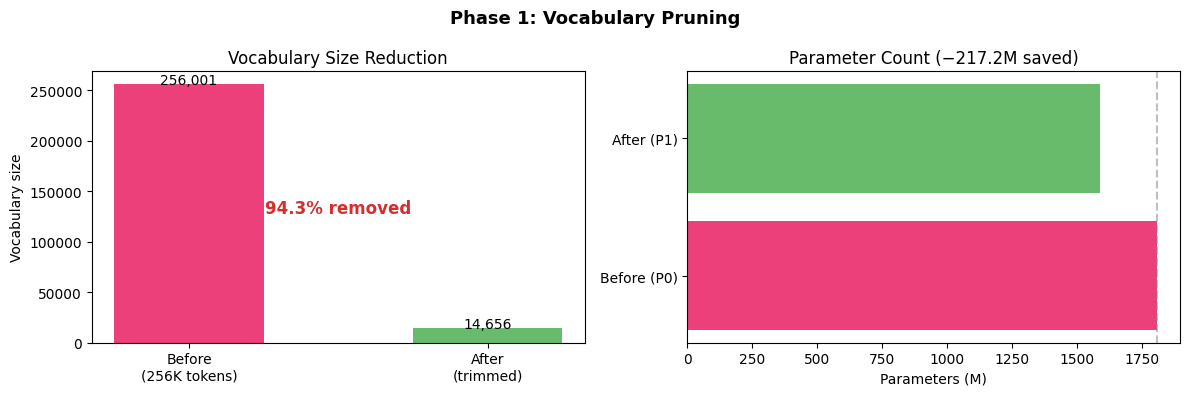

KeyboardInterrupt: 

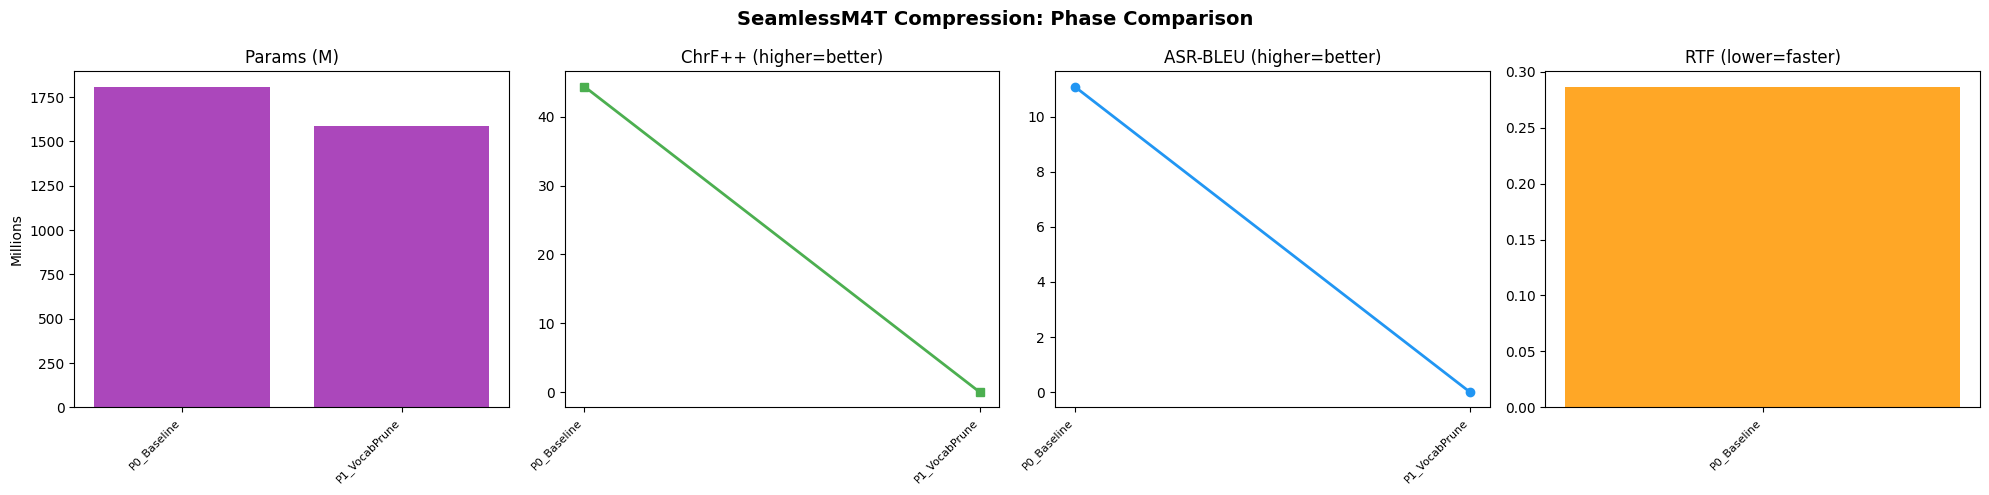

In [45]:
# Phase 1 Benchmark + Visualisation
p1b = load_latest_checkpoint('phase1_benchmark')
if p1b:
    p1_summary = p1b['summary']
    print(f'Loaded P1: ChrF++={p1_summary["avg_chrf"]:.2f}')
else:
    p1_summary = run_benchmark(model_p1, eval_samples, label='P1_VocabPrune',
                               save_n=4, use_asr_bleu=False)  # no asr-bleu: fast phase
    save_checkpoint({'summary': p1_summary}, name='phase1_benchmark', step=0)

store_summary(p1_summary)

# Visualise vocab reduction
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Phase 1: Vocabulary Pruning', fontweight='bold', fontsize=13)

labels_bar = ['Before\n(256K tokens)', 'After\n(trimmed)']
sizes_bar  = [processor.tokenizer.vocab_size, len(used_ids)]
colors_bar = ['#E91E63', '#4CAF50']
axes[0].bar(labels_bar, sizes_bar, color=colors_bar, alpha=0.85, width=0.5)
axes[0].set_ylabel('Vocabulary size')
axes[0].set_title('Vocabulary Size Reduction')
for i, v in enumerate(sizes_bar):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
axes[0].annotate(f'{(1-sizes_bar[1]/sizes_bar[0])*100:.1f}% removed',
                 xy=(0.5, max(sizes_bar)*0.5), ha='center', fontsize=12,
                 fontweight='bold', color='#d32f2f')

params_before = p0_summary['params_M']
params_after  = p1_summary['params_M']
delta = params_before - params_after
axes[1].barh(['Before (P0)', 'After (P1)'], [params_before, params_after],
             color=['#E91E63', '#4CAF50'], alpha=0.85)
axes[1].set_xlabel('Parameters (M)')
axes[1].set_title(f'Parameter Count (−{delta:.1f}M saved)')
axes[1].axvline(params_before, color='gray', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase1_vocab.png', dpi=130, bbox_inches='tight')
plt.show()

plot_phase_comparison()


---
# Phase 2: Text Encoder Removal (S2S-only)
**Paper:** Architecture analysis (SeamlessM4T paper, §4)

For the `SeamlessM4Tv2ForSpeechToSpeech` forward pass:
`speech_encoder → adaptor → text_decoder → t2u → vocoder`

The **text encoder is never invoked** for S2ST input. It only activates
for T2TT and T2ST tasks. Removing it saves ~350M parameters with no
regression for our English→Bengali S2ST pipeline.

**Metric:** ChrF++ only.


In [ ]:
# Phase 2 Cell 1: Verify text encoder is unused in S2ST
import functools

_te_called = [False]
if hasattr(model_p1, 'text_encoder'):
    _orig_te_fwd = model_p1.text_encoder.forward
    def _patched_fwd(*args, **kwargs):
        _te_called[0] = True
        return _orig_te_fwd(*args, **kwargs)
    model_p1.text_encoder.forward = _patched_fwd

    _test_wav = eval_samples[0]['wav']
    _ = run_s2st(model_p1, _test_wav)

    if _te_called[0]:
        print('WARNING: text_encoder WAS called — do NOT remove it blindly.')
        print('Only prune (remove 8–12 layers) instead.')
    else:
        print('✅ Confirmed: text_encoder is NOT called during S2ST forward pass.')
        print('   Safe to remove entirely.')

    model_p1.text_encoder.forward = _orig_te_fwd  # restore
else:
    print('No text_encoder found (already removed?).')


In [ ]:
# Phase 2 Cell 2: Remove text encoder

p2_ckpt = load_latest_checkpoint('phase2_te_removed')

if p2_ckpt:
    model_p2, processor = load_model_from_drive('phase2_te_removed')
    print('Loaded Phase 2 from Drive.')
else:
    model_p2 = _copy.deepcopy(model_p1)

    if hasattr(model_p2, 'text_encoder'):
        te_params = count_params(model_p2.text_encoder)
        del model_p2.text_encoder
        print(f'Text encoder removed ({te_params:.1f}M params freed).')
    else:
        print('No text_encoder to remove.')

    # Disable in config so HF doesn't try to instantiate it on reload
    model_p2.config.encoder_layers = 0

    _sync_config_to_architecture(model_p2)
    save_model_to_drive(model_p2, processor, 'phase2_te_removed')
    save_checkpoint({'te_removed': True}, name='phase2_te_removed', step=0)

print_model_breakdown(model_p2, 'After Phase 2: Text Encoder Removed')


In [ ]:
# Phase 2 Benchmark + Visualisation
p2b = load_latest_checkpoint('phase2_benchmark')
if p2b:
    p2_summary = p2b['summary']
    print(f'Loaded P2: ChrF++={p2_summary["avg_chrf"]:.2f}')
else:
    p2_summary = run_benchmark(model_p2, eval_samples, label='P2_TERemoved',
                               save_n=4, use_asr_bleu=False)
    save_checkpoint({'summary': p2_summary}, name='phase2_benchmark', step=0)

store_summary(p2_summary)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Phase 2: Text Encoder Removal', fontweight='bold', fontsize=13)

phases_so_far = [s for s in ALL_SUMMARIES if s['label'] in
                 ['P0_Baseline', 'P1_VocabPrune', 'P2_TERemoved']]
labels_v  = [s['label'] for s in phases_so_far]
params_v  = [s['params_M'] for s in phases_so_far]
chrf_v    = [s['avg_chrf'] for s in phases_so_far]

axes[0].bar(range(len(labels_v)), params_v, color='#9C27B0', alpha=0.85)
axes[0].set_xticks(range(len(labels_v)))
axes[0].set_xticklabels(labels_v, rotation=25, ha='right', fontsize=9)
axes[0].set_title('Params (M)'); axes[0].set_ylabel('Millions')

axes[1].plot(range(len(labels_v)), chrf_v, 's-', color='#4CAF50', lw=2)
axes[1].set_xticks(range(len(labels_v)))
axes[1].set_xticklabels(labels_v, rotation=25, ha='right', fontsize=9)
axes[1].set_title('ChrF++ (S2TT path)'); axes[1].set_ylabel('ChrF++')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase2_te_removal.png', dpi=130, bbox_inches='tight')
plt.show()
plot_phase_comparison()


---
# Phase 3: FLAP Width Pruning — FFN neurons (text_decoder + speech_encoder, NOT t2u)
**Paper:** An et al., FLAP (AAAI 2024) + Wanda-sp (ICLR 2024)

## Why FLAP comes BEFORE layer pruning
Layer pruning forces the surviving layers to **absorb context** from removed
layers. Once that redistribution has happened, each remaining layer's neurons
are individually more critical → FLAP becomes destructive at the same pruning
ratio that worked fine on the unperturbed model.

Running FLAP first on the **fat, unperturbed** architecture removes genuinely
idle neurons (those already below activation threshold regardless of layer
interactions). Then layer pruning removes entire layers at the coarser level.

## Scope: text_decoder + speech_encoder ONLY
T2U has its own dedicated conservative phase (Phase 6). FLAP on T2U at this
stage would corrupt the audio path before we have fine-tuning in place.

## Metrics
**ChrF++ AND ASR-BLEU** — we are now modifying layer width, which directly
affects both the text decoder output AND (indirectly) the speech encoder
representations fed to T2U.


In [ ]:
# ── Phase 3 Cell 1: FFN layer discovery ──────────────────────────────────────

def find_all_ffn_layers(mdl, component_name):
    component = getattr(mdl, component_name)
    results = []

    def _pair_ok(lin1, lin2):
        return (isinstance(lin1, nn.Linear) and isinstance(lin2, nn.Linear)
                and lin1.out_features == lin2.in_features)

    def _scan(module, prefix):
        if hasattr(module, 'intermediate_dense') and hasattr(module, 'output_dense'):
            if _pair_ok(module.intermediate_dense, module.output_dense):
                results.append((module, 'intermediate_dense', 'output_dense', prefix))
        if hasattr(module, 'fc1') and hasattr(module, 'fc2'):
            if _pair_ok(module.fc1, module.fc2):
                results.append((module, 'fc1', 'fc2', prefix))
        for name, child in module.named_children():
            if not isinstance(child, nn.Linear):
                _scan(child, f'{prefix}.{name}' if prefix else name)

    _scan(component, component_name)
    return results

# Test detection
for comp in ['speech_encoder', 'text_decoder']:
    pairs = find_all_ffn_layers(model_p2, comp)
    print(f'  {comp}: {len(pairs)} FFN pairs found')
    if pairs:
        fc1 = getattr(pairs[0][0], pairs[0][1])
        print(f'    First: {pairs[0][3]} | {fc1.in_features}→{fc1.out_features}')


In [ ]:
# ── Phase 3 Cell 2: Calibration stat collection ───────────────────────────────

def collect_ffn_calibration_stats(mdl, component_name, calibration_wavs,
                                   n_samples=64, device=None):
    if device is None:
        device = next(mdl.parameters()).device

    ffn_pairs = find_all_ffn_layers(mdl, component_name)
    if not ffn_pairs:
        print(f'  No FFN pairs in {component_name}, skipping.')
        return {}

    stats = {}
    for (parent, fc1_attr, fc2_attr, name) in ffn_pairs:
        fc1 = getattr(parent, fc1_attr)
        cin = fc1.in_features
        key = id(parent)
        stats[key] = {
            'sum_x': torch.zeros(cin, dtype=torch.float64),
            'sq_sum': torch.zeros(cin, dtype=torch.float64),
            'count': 0, 'module': parent,
            'fc1': fc1_attr, 'fc2': fc2_attr, 'name': name,
        }

    hooks = []
    def make_hook(key):
        def hook(module, inp, out):
            x = inp[0].detach().float()
            if x.dim() == 3: x = x.reshape(-1, x.shape[-1])
            elif x.dim() == 1: x = x.unsqueeze(0)
            s = stats[key]
            s['count']  += x.shape[0]
            s['sum_x']  += x.sum(dim=0).double()
            s['sq_sum'] += x.pow(2).sum(dim=0).double()
        return hook

    for (parent, fc1_attr, _, _) in ffn_pairs:
        fc1 = getattr(parent, fc1_attr)
        hooks.append(fc1.register_forward_hook(make_hook(id(parent))))

    mdl.eval()
    n_actual = min(n_samples, len(calibration_wavs))
    print(f'  Collecting activations for {component_name} ({n_actual} samples via generate)...')

    with torch.no_grad():
        for i, wav in enumerate(calibration_wavs[:n_actual]):
            if i % 20 == 0: print(f'  {i}/{n_actual}')
            try:
                inputs = processor(audio=wav, sampling_rate=SAMPLE_RATE, return_tensors='pt')
                sp_dev = next(mdl.speech_encoder.parameters()).device
                inputs = {k: v.to(sp_dev) for k, v in inputs.items()}
                mdl.generate(**inputs, tgt_lang='ben', generate_speech=False, max_new_tokens=40)
            except: pass

    for h in hooks: h.remove()

    fired = sum(1 for s in stats.values() if s['count'] > 0)
    print(f'  Fired: {fired}/{len(stats)}')

    for s in stats.values():
        n = max(s['count'], 1)
        mean_x  = (s['sum_x'] / n).float()
        sq_norm = (s['sq_sum'] / n).float()
        var     = (sq_norm - mean_x.pow(2)).clamp(min=0)
        s['mean'] = mean_x; s['var'] = var; s['sq_norm'] = sq_norm

    return stats

print('Calibration helper ready.')


In [ ]:
# ── Phase 3 Cell 3: Neuron importance scoring + structural pruning ────────────

def neuron_importance_scores(fc1_weight, var_x, sq_norm=None):
    W1 = fc1_weight.float().cpu()
    if sq_norm is not None and sq_norm.max().item() > 1e-10:
        rms = sq_norm.float().cpu().clamp(min=0).sqrt()
        return (W1.abs() * rms.unsqueeze(0)).sum(dim=1)   # Wanda-sp
    if var_x is not None and var_x.max().item() > 1e-10:
        v = var_x.float().cpu().clamp(min=0)
        return (W1.pow(2) * v.unsqueeze(0)).sum(dim=1)    # FLAP
    return W1.pow(2).sum(dim=1)                            # fallback: weight norm

def standardize_scores(scores):
    mu = scores.mean(); sigma = scores.std(unbiased=False)
    if sigma < 1e-8: return torch.zeros_like(scores)
    return (scores - mu) / sigma

def structural_prune_ffn(parent, fc1_attr, fc2_attr, channel_mean, keep_idx, device):
    fc1, fc2 = getattr(parent, fc1_attr), getattr(parent, fc2_attr)
    ffn_dim  = fc1.out_features
    d1, d2   = fc1.weight.device, fc2.weight.device

    all_idx    = torch.arange(ffn_dim)
    pruned_mask = torch.ones(ffn_dim, dtype=torch.bool)
    pruned_mask[keep_idx] = False
    pruned_idx = all_idx[pruned_mask]

    mean_x = channel_mean.to(d1).to(fc1.weight.dtype)
    if len(pruned_idx) > 0:
        pidx     = pruned_idx.to(d1)
        baseline = fc1.weight.data[pidx] @ mean_x
        if fc1.bias is not None: baseline = baseline + fc1.bias.data[pidx]
        bias_comp = (fc2.weight.data[:, pidx.to(d2)].float()
                     @ baseline.float().to(d2)).to(fc2.weight.dtype)
    else:
        bias_comp = torch.zeros(fc2.out_features, dtype=fc2.weight.dtype, device=d2)

    n_keep   = len(keep_idx)
    kidx_fc1 = keep_idx.to(d1); kidx_fc2 = keep_idx.to(d2)

    new_fc1 = nn.Linear(fc1.in_features, n_keep, bias=(fc1.bias is not None),
                         device=d1, dtype=fc1.weight.dtype)
    new_fc1.weight.data.copy_(fc1.weight.data[kidx_fc1])
    if fc1.bias is not None: new_fc1.bias.data.copy_(fc1.bias.data[kidx_fc1])

    new_fc2 = nn.Linear(n_keep, fc2.out_features, bias=True, device=d2, dtype=fc2.weight.dtype)
    new_fc2.weight.data.copy_(fc2.weight.data[:, kidx_fc2])
    existing_b = fc2.bias.data if fc2.bias is not None else torch.zeros(
        fc2.out_features, dtype=fc2.weight.dtype, device=d2)
    new_fc2.bias.data.copy_(existing_b + bias_comp.to(d2))

    setattr(parent, fc1_attr, new_fc1)
    setattr(parent, fc2_attr, new_fc2)
    return n_keep, ffn_dim

print('FLAP neuron scoring + structural prune ready.')


In [ ]:
# ── Phase 3 Cell 4: Apply FLAP to one component ───────────────────────────────

def apply_flap_to_component(mdl, component_name, calib_stats,
                              global_prune_ratio=0.20, min_keep_frac=0.50, device=None):
    if device is None: device = next(mdl.parameters()).device
    if not calib_stats:
        print(f'  No calib stats for {component_name}, skipping.'); return {}

    all_std, all_raw = {}, {}
    for key, s in calib_stats.items():
        fc1 = getattr(s['module'], s['fc1'])
        W1  = fc1.weight.float().cpu()
        raw = neuron_importance_scores(W1, s.get('var'), s.get('sq_norm'))
        all_raw[key]  = raw
        all_std[key] = standardize_scores(raw)

    all_flat  = torch.cat(list(all_std.values()))
    total_n   = len(all_flat)
    n_prune   = int(total_n * global_prune_ratio)
    sorted_s, _ = torch.sort(all_flat)
    threshold = sorted_s[max(0, n_prune - 1)].item()

    print(f'  {component_name}: {total_n} neurons, prune ≤{n_prune} '
          f'({global_prune_ratio*100:.0f}%), thresh={threshold:.4f}')

    results = {}
    total_kept = total_orig = 0
    for key, s in calib_stats.items():
        std  = all_std[key]
        fc1  = getattr(s['module'], s['fc1'])
        ffn_dim = fc1.out_features
        n_above = int((std > threshold).sum().item())
        min_keep = max(1, int(ffn_dim * min_keep_frac))
        n_keep   = max(min_keep, n_above)
        n_keep   = min(ffn_dim, n_keep)
        _, keep_idx = torch.topk(std, n_keep)
        keep_idx = keep_idx.sort().values
        structural_prune_ffn(s['module'], s['fc1'], s['fc2'],
                             channel_mean=s['mean'], keep_idx=keep_idx, device=device)
        total_kept += n_keep; total_orig += ffn_dim
        results[s['name']] = {'kept': n_keep, 'original': ffn_dim, 'pct': n_keep/ffn_dim*100}

    print(f'  Done. Kept {total_kept}/{total_orig} neurons '
          f'({total_kept/max(total_orig,1)*100:.1f}%) across {len(results)} layers.')
    return results

print('apply_flap_to_component ready.')


In [ ]:
# ── Phase 3 Cell 5: RUN FLAP on text_decoder + speech_encoder ────────────────
import gc as _gc
import copy as _copy

FLAP_RATIO    = 0.20    # prune 20% globally per component
MIN_KEEP_FRAC = 0.60    # never shrink any single layer below 60%

p3_ckpt = load_latest_checkpoint('phase3_flap')

if p3_ckpt and os.path.isdir(f'{MODEL_DIR}/phase3_flap_pruned'):
    model_p3, processor = load_model_from_drive('phase3_flap_pruned')
    sync_model_config(model_p3)
    model_p3 = _consolidate_to_single_gpu(model_p3)
    print('Loaded Phase 3 from Drive.')
else:
    print('Running FLAP width pruning (text_decoder + speech_encoder)...')
    model_p3 = _copy.deepcopy(model_p2)
    model_p3 = _consolidate_to_single_gpu(model_p3)
    device   = next(model_p3.parameters()).device

    pre_params = count_params(model_p3)
    calib_wavs = [s['wav'] for s in eval_samples]
    prune_results = {}

    for comp in ['text_decoder', 'speech_encoder']:   # ← NO t2u_model here
        print(f'\n── Calibrating {comp} ──')
        calib = collect_ffn_calibration_stats(
            model_p3, comp, calib_wavs,
            n_samples=min(64, len(calib_wavs)), device=device)
        _gc.collect(); torch.cuda.empty_cache()

        print(f'\n── Applying FLAP to {comp} ──')
        res = apply_flap_to_component(model_p3, comp, calib,
                                      global_prune_ratio=FLAP_RATIO,
                                      min_keep_frac=MIN_KEEP_FRAC, device=device)
        prune_results[comp] = res
        _gc.collect(); torch.cuda.empty_cache()

    post_params = count_params(model_p3)
    print(f'\nWidth pruning: {pre_params:.1f}M → {post_params:.1f}M '
          f'(−{pre_params - post_params:.1f}M)')

    sync_model_config(model_p3)
    save_checkpoint({'prune_results': prune_results, 'flap_ratio': FLAP_RATIO},
                    name='phase3_flap', step=0)
    save_model_to_drive(model_p3, processor, 'phase3_flap_pruned')

print_model_breakdown(model_p3, 'After Phase 3: FLAP Width Pruned')


In [ ]:
# Phase 3 Benchmark + Visualisation
p3b = load_latest_checkpoint('phase3_benchmark')
if p3b:
    p3_summary = p3b['summary']
    print(f'Loaded P3: ChrF++={p3_summary["avg_chrf"]:.2f}  ASR-BLEU={p3_summary["asr_bleu"]:.2f}')
else:
    p3_summary = run_benchmark(model_p3, eval_samples, label='P3_FLAP',
                               save_n=4, use_asr_bleu=True)   # ← ASR-BLEU ON
    save_checkpoint({'summary': p3_summary}, name='phase3_benchmark', step=0)

store_summary(p3_summary)

# Sanity: quick check that audio output still sounds reasonable
print('\nQuick audio sanity check (3 samples):')
for i, s in enumerate(eval_samples[:3]):
    try:
        pred, wav = run_s2st(model_p3, s['wav'])
        chrf = compute_chrf(pred, s['ref'])
        print(f'  [{i+1}] ChrF++={chrf:.1f}  audio_len={len(wav)/SAMPLE_RATE:.1f}s  '
              f'pred: {pred[:60]}')
        play(wav, SAMPLE_RATE)
    except Exception as e:
        print(f'  [{i+1}] ERROR: {e}')

plot_phase_comparison()


In [ ]:
# Phase 3 FLAP Analysis Plot
p3_ckpt = load_latest_checkpoint('phase3_flap')
if p3_ckpt and 'prune_results' in p3_ckpt:
    pr = p3_ckpt['prune_results']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Phase 3: FLAP Width Pruning Analysis', fontweight='bold', fontsize=13)

    for ax_i, comp in enumerate(['text_decoder', 'speech_encoder']):
        if comp not in pr: continue
        res = pr[comp]
        layer_names = list(res.keys())
        pcts = [res[n]['pct'] for n in layer_names]
        x = range(len(layer_names))
        colors = ['#4CAF50' if p >= 70 else '#FF9800' if p >= 55 else '#d32f2f'
                  for p in pcts]
        axes[ax_i].bar(x, pcts, color=colors, alpha=0.85)
        axes[ax_i].axhline(100, color='black', ls='--', alpha=0.3, lw=1)
        axes[ax_i].axhline(np.mean(pcts), color='red', ls='--', lw=1.5,
                           label=f'Mean={np.mean(pcts):.1f}%')
        axes[ax_i].set_title(f'{comp}: % Neurons Kept', fontweight='bold')
        axes[ax_i].set_xlabel('FFN Layer index')
        axes[ax_i].set_ylabel('% Neurons Kept')
        axes[ax_i].set_ylim(0, 110)
        axes[ax_i].legend(fontsize=9)
        axes[ax_i].set_xticks(list(x)[::max(1, len(x)//10)])

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/phase3_flap_analysis.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved phase3_flap_analysis.png')


---
# Phase 4: Text Decoder Iterative Layer Pruning
**Paper:** Moslem (IWSLT 2025) + CULL-MT (arXiv 2411.06506)

Greedily remove the decoder layer whose absence causes the **least ChrF++
degradation**, one at a time. Target: remove 6–8 of 24 layers.

CULL-MT showed NLLB-3.3B (same backbone) tolerates 25% layer removal with
only 0.9 spBLEU drop when guided by task performance, not proxy metrics.

**Metric:** ChrF++ (fast — uses S2TT path, no vocoder).


In [ ]:
# Phase 4 Cell 1: Text decoder layer utils

def reindex_text_decoder_layer_idx(mdl):
    for i, layer in enumerate(mdl.text_decoder.layers):
        for attn_name in ['self_attn', 'encoder_attn', 'cross_attention']:
            attn = getattr(layer, attn_name, None)
            if attn is not None and hasattr(attn, 'layer_idx'):
                attn.layer_idx = i
    print(f'Re-indexed text_decoder: {len(mdl.text_decoder.layers)} layers')

def iterative_layer_prune(mdl, component_attr, layers_attr,
                           samples, n_remove,
                           tgt_lang='ben', max_eval=10,
                           protected_first=1, protected_last=1,
                           ckpt_name=None):
    """Greedy iterative layer pruning. Protects first/last layers."""
    import torch.nn as nn

    if ckpt_name is None:
        ckpt_name = f'iterative_{component_attr}_pruning'

    component = getattr(mdl, component_attr)
    current   = list(getattr(component, layers_attr))
    orig_idx  = list(range(len(current)))
    n_orig    = len(current)

    n_remove = min(n_remove, n_orig - protected_first - protected_last - 1)
    protected_set = set(range(protected_first)) | set(range(n_orig - protected_last, n_orig))
    print(f'{component_attr}: {n_orig} layers, removing {n_remove}, '
          f'protected={sorted(protected_set)}')

    removed, log = [], []
    # Resume
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_idx:
                pos = orig_idx.index(r)
                current.pop(pos); orig_idx.pop(pos)
        setattr(component, layers_attr, nn.ModuleList(current))
        print(f'Resuming: already removed {removed}, {len(current)} layers remain')

    baseline = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
    print(f'Baseline ChrF++: {baseline:.2f}')

    start = len(removed)
    for it in range(start, n_remove):
        eligible = [i for i, orig in enumerate(orig_idx) if orig not in protected_set]
        if not eligible:
            print('No eligible layers left.'); break

        print(f'\nIter {it+1}/{n_remove} ({len(current)} layers, {len(eligible)} eligible)')
        scores = {}
        for pos in eligible:
            temp = current[:pos] + current[pos+1:]
            setattr(component, layers_attr, nn.ModuleList(temp))
            sc = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
            scores[pos] = (orig_idx[pos], sc)
            print(f'  Remove L{orig_idx[pos]:>2} -> ChrF++={sc:.2f}')
        setattr(component, layers_attr, nn.ModuleList(current))  # restore

        best_pos = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_pos]
        current.pop(best_pos); orig_idx.pop(best_pos)
        setattr(component, layers_attr, nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, chrf=best_sc, remaining=len(current)))
        print(f'  → Removed L{best_orig} (ChrF++={best_sc:.2f}, {len(current)} remain)')
        save_checkpoint({'removed': removed, 'log': log}, name=ckpt_name, step=0)
        torch.cuda.empty_cache()

    return removed, log

print('Iterative layer prune helper ready.')


In [ ]:
# Phase 4 Cell 2: RUN text decoder pruning

N_DEC_REMOVE = 7  # remove 7 of 24 decoder layers (~29%)

p4_ckpt = load_latest_checkpoint('phase4_dec_pruning')

if p4_ckpt and os.path.isdir(f'{MODEL_DIR}/phase4_dec_pruned'):
    model_p4, processor = load_model_from_drive('phase4_dec_pruned')
    sync_model_config(model_p4); model_p4 = _consolidate_to_single_gpu(model_p4)
    print('Loaded Phase 4 from Drive.')
else:
    model_p4 = _copy.deepcopy(model_p3)
    model_p4 = _consolidate_to_single_gpu(model_p4)

    removed_dec, log_dec = iterative_layer_prune(
        model_p4, 'text_decoder', 'layers',
        eval_samples, n_remove=N_DEC_REMOVE,
        tgt_lang=TGT_LANG, max_eval=10,
        protected_first=1, protected_last=1,
        ckpt_name='phase4_dec_pruning')

    reindex_text_decoder_layer_idx(model_p4)
    sync_model_config(model_p4)

    save_checkpoint({'removed': removed_dec, 'log': log_dec},
                    name='phase4_dec_pruning', step=0)
    save_model_to_drive(model_p4, processor, 'phase4_dec_pruned',
                        manifest_extra={'dec_removed': removed_dec})

print_model_breakdown(model_p4, 'After Phase 4: Text Decoder Pruned')


In [ ]:
# Phase 4 Benchmark + Visualisation
p4b = load_latest_checkpoint('phase4_benchmark')
if p4b:
    p4_summary = p4b['summary']
    print(f'Loaded P4: ChrF++={p4_summary["avg_chrf"]:.2f}')
else:
    p4_summary = run_benchmark(model_p4, eval_samples, label='P4_DecPrune',
                               save_n=4, use_asr_bleu=False)  # fast: no asr-bleu
    save_checkpoint({'summary': p4_summary}, name='phase4_benchmark', step=0)

store_summary(p4_summary)

# Decoder pruning visualisation
p4_ckpt = load_latest_checkpoint('phase4_dec_pruning')
if p4_ckpt and p4_ckpt.get('log'):
    log = p4_ckpt['log']
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Phase 4: Text Decoder Iterative Layer Pruning', fontweight='bold', fontsize=13)

    iters = [e['iter'] for e in log]
    chrfs = [e['chrf'] for e in log]
    axes[0].plot(iters, chrfs, 'o-', color='#4CAF50', lw=2)
    for e in log:
        axes[0].annotate(f'L{e["removed"]}', (e['iter'], e['chrf']),
                         fontsize=8, textcoords='offset points', xytext=(0, 6))
    axes[0].axhline(p3_summary.get('avg_chrf', 0), color='red', ls='--', lw=1,
                    label='P3 baseline')
    axes[0].set_title('ChrF++ After Each Layer Removal')
    axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('ChrF++')
    axes[0].legend(fontsize=9)

    remaining = [log[0]['remaining'] + 1] + [e['remaining'] for e in log]
    iters2 = [0] + iters
    axes[1].plot(iters2, remaining, 's-', color='#9C27B0', lw=2)
    axes[1].set_title('Remaining Decoder Layers')
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Layers')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/phase4_dec_pruning.png', dpi=130, bbox_inches='tight')
    plt.show()

plot_phase_comparison()


---
# Phase 5: Speech Encoder Iterative Layer Pruning
**Paper:** ShortGPT / Block Influence (ACL 2025) + Moslem (IWSLT 2025)

Remove redundant speech encoder (Conformer) layers guided by:
1. Block Influence (BI) score for rapid candidate ranking
2. Iterative greedy pruning with actual ChrF++ evaluation (from Phase 3 onward)

Target: remove 6–8 of 24 encoder layers.
**Metric:** ChrF++ only.


In [ ]:
# Phase 5 Cell 1: Speech encoder layer utils

def reindex_speech_encoder_layer_idx(mdl):
    enc = mdl.speech_encoder
    layers = None
    for parent in [enc, getattr(enc, 'encoder', None)]:
        if parent:
            layers = _find_layers(parent)
            if layers: break
    if layers is None:
        for _, child in enc.named_children():
            layers = _find_layers(child)
            if layers: break
    if layers:
        for i, layer in enumerate(layers):
            for attn_name in ['self_attn', 'attn']:
                attn = getattr(layer, attn_name, None)
                if attn is not None and hasattr(attn, 'layer_idx'):
                    attn.layer_idx = i
        print(f'Re-indexed speech_encoder: {len(layers)} layers')

def _find_enc_layers_parent(mdl):
    enc = mdl.speech_encoder
    for parent in [enc, getattr(enc, 'encoder', None)]:
        if parent:
            layers = _find_layers(parent)
            if layers: return parent, layers
    for _, child in enc.named_children():
        layers = _find_layers(child)
        if layers: return child, layers
    return None, None

def iterative_enc_prune(mdl, samples, n_remove,
                         tgt_lang='ben', max_eval=10,
                         protected_first=1, protected_last=2,
                         ckpt_name='phase5_enc_pruning'):
    """Iterative speech encoder layer pruning."""
    import torch.nn as nn

    parent, current_layers = _find_enc_layers_parent(mdl)
    if parent is None:
        print('ERROR: cannot locate speech encoder layers'); return [], []

    # Find which ModuleList attribute name contains these layers
    layers_attr = None
    for attr in ['layers', 'inner_layers', 'layer']:
        mod = getattr(parent, attr, None)
        if isinstance(mod, nn.ModuleList) and mod is current_layers:
            layers_attr = attr; break
    if layers_attr is None:
        print('ERROR: cannot identify layers_attr'); return [], []

    current  = list(current_layers)
    orig_idx = list(range(len(current)))
    n_orig   = len(current)
    n_remove = min(n_remove, n_orig - protected_first - protected_last - 1)
    protected = set(range(protected_first)) | set(range(n_orig - protected_last, n_orig))
    print(f'speech_encoder: {n_orig} layers, removing {n_remove}, protected={sorted(protected)}')

    removed, log = [], []
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_idx:
                pos = orig_idx.index(r)
                current.pop(pos); orig_idx.pop(pos)
        setattr(parent, layers_attr, nn.ModuleList(current))
        print(f'Resuming: removed {removed}, {len(current)} layers remain')

    baseline = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
    print(f'Baseline ChrF++: {baseline:.2f}')

    start = len(removed)
    for it in range(start, n_remove):
        eligible = [i for i, orig in enumerate(orig_idx) if orig not in protected]
        if not eligible: break
        print(f'\nIter {it+1}/{n_remove} ({len(current)} enc layers, {len(eligible)} eligible)')
        scores = {}
        for pos in eligible:
            temp = current[:pos] + current[pos+1:]
            setattr(parent, layers_attr, nn.ModuleList(temp))
            sc = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
            scores[pos] = (orig_idx[pos], sc)
            print(f'  Remove L{orig_idx[pos]:>2} -> ChrF++={sc:.2f}')
        setattr(parent, layers_attr, nn.ModuleList(current))

        best_pos = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_pos]
        current.pop(best_pos); orig_idx.pop(best_pos)
        setattr(parent, layers_attr, nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, chrf=best_sc, remaining=len(current)))
        print(f'  → Removed L{best_orig} (ChrF++={best_sc:.2f}, {len(current)} remain)')
        save_checkpoint({'removed': removed, 'log': log}, name=ckpt_name, step=0)
        torch.cuda.empty_cache()

    return removed, log

print('Speech encoder iterative prune helper ready.')


In [ ]:
# Phase 5 Cell 2: RUN speech encoder pruning

N_ENC_REMOVE = 7   # remove 7 of 24 conformer layers

p5_ckpt = load_latest_checkpoint('phase5_enc_pruning')

if p5_ckpt and os.path.isdir(f'{MODEL_DIR}/phase5_enc_pruned'):
    model_p5, processor = load_model_from_drive('phase5_enc_pruned')
    sync_model_config(model_p5); model_p5 = _consolidate_to_single_gpu(model_p5)
    print('Loaded Phase 5 from Drive.')
else:
    model_p5 = _copy.deepcopy(model_p4)
    model_p5 = _consolidate_to_single_gpu(model_p5)

    removed_enc, log_enc = iterative_enc_prune(
        model_p5, eval_samples, n_remove=N_ENC_REMOVE,
        tgt_lang=TGT_LANG, max_eval=10,
        protected_first=1, protected_last=2,
        ckpt_name='phase5_enc_pruning')

    reindex_speech_encoder_layer_idx(model_p5)
    sync_model_config(model_p5)

    save_checkpoint({'removed': removed_enc, 'log': log_enc},
                    name='phase5_enc_pruning', step=0)
    save_model_to_drive(model_p5, processor, 'phase5_enc_pruned',
                        manifest_extra={'enc_removed': removed_enc})

print_model_breakdown(model_p5, 'After Phase 5: Speech Encoder Pruned')


In [ ]:
# Phase 5 Benchmark + Visualisation
p5b = load_latest_checkpoint('phase5_benchmark')
if p5b:
    p5_summary = p5b['summary']
    print(f'Loaded P5: ChrF++={p5_summary["avg_chrf"]:.2f}')
else:
    p5_summary = run_benchmark(model_p5, eval_samples, label='P5_EncPrune',
                               save_n=4, use_asr_bleu=False)
    save_checkpoint({'summary': p5_summary}, name='phase5_benchmark', step=0)

store_summary(p5_summary)

# Enc pruning visualisation
p5_ckpt = load_latest_checkpoint('phase5_enc_pruning')
if p5_ckpt and p5_ckpt.get('log'):
    log = p5_ckpt['log']
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Phase 5: Speech Encoder Iterative Layer Pruning', fontweight='bold', fontsize=13)

    iters = [e['iter'] for e in log]
    chrfs = [e['chrf'] for e in log]
    axes[0].plot(iters, chrfs, 'o-', color='#2196F3', lw=2)
    for e in log:
        axes[0].annotate(f'L{e["removed"]}', (e['iter'], e['chrf']),
                         fontsize=8, textcoords='offset points', xytext=(0, 6))
    axes[0].axhline(p4_summary.get('avg_chrf', 0), color='red', ls='--', lw=1,
                    label='P4 baseline')
    axes[0].set_title('ChrF++ After Each Encoder Layer Removal')
    axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('ChrF++')
    axes[0].legend(fontsize=9)

    axes[1].bar(iters, chrfs, color=['#d32f2f' if c < p4_summary.get('avg_chrf',0)*0.9
                                     else '#4CAF50' for c in chrfs], alpha=0.85)
    axes[1].set_title('ChrF++ per Removal (green=acceptable drop)')
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('ChrF++')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/phase5_enc_pruning.png', dpi=130, bbox_inches='tight')
    plt.show()

plot_phase_comparison()


---
# Phase 6: T2U Model Conservative Layer Pruning
**Paper:** Iterative layer pruning (same as Phases 4–5)

⚠️ **T2U is the most fragile component.** It converts text tokens to discrete
speech units that drive the vocoder. Even 1–2 layers removed can produce silent
or garbled audio while keeping the text output healthy (because the ChrF++ from
the text decoder path won't catch the audio corruption).

## Dual-metric monitoring
Both **ChrF++** (text path) and **ASR-BLEU via MMS-1B** (audio path) are
tracked at every iteration. If ASR-BLEU drops >3 points from baseline,
the iteration is **reverted** and pruning stops for that stack.

## Conservative settings
- Maximum 2 layers removed per stack (encoder + decoder → 4 total max)
- `protected_first=1`, `protected_last=1` (never touch first/last layer)
- Immediate revert if audio quality collapses


In [ ]:
# Phase 6 Cell 1: T2U stack discovery + sync utilities

def find_t2u_stacks(mdl):
    t2u = mdl.t2u_model
    stacks = []
    def _search(module, prefix):
        for attr in ['layers', 'inner_layers', 'encoder_layers', 'decoder_layers']:
            if hasattr(module, attr):
                layers = getattr(module, attr)
                if isinstance(layers, nn.ModuleList) and len(layers) >= 3:
                    stacks.append((module, attr, f't2u.{prefix}.{attr}'))
        for name, child in module.named_children():
            _search(child, f'{prefix}.{name}' if prefix else name)
    _search(t2u, 't2u_model')
    return stacks

def sync_t2u_layer_indices(mdl):
    for (parent, attr, name) in find_t2u_stacks(mdl):
        layers = list(getattr(parent, attr))
        for i, layer in enumerate(layers):
            for attn_name in ['self_attn', 'encoder_attn', 'cross_attention']:
                attn = getattr(layer, attn_name, None)
                if attn is not None and hasattr(attn, 'layer_idx'):
                    attn.layer_idx = i
        print(f'  Re-indexed {name}: {len(layers)} layers')

# Inspect T2U stacks
stacks_pre = find_t2u_stacks(model_p5)
print(f'Found {len(stacks_pre)} T2U stacks:')
for (parent, attr, name) in stacks_pre:
    layers = getattr(parent, attr)
    print(f'  {name}: {len(layers)} layers')


In [ ]:
# Phase 6 Cell 2: T2U iterative pruning with dual-metric guard

def iterative_prune_t2u_stack_guarded(mdl, stack_parent, layers_attr, stack_name,
                                       samples, n_remove_max,
                                       asr_bleu_baseline, chrf_baseline,
                                       asr_bleu_drop_limit=3.0, chrf_drop_limit=2.0,
                                       tgt_lang='ben', max_eval=8, ckpt_name=None):
    """
    T2U iterative pruning with hard revert guard.
    Stops and reverts if ASR-BLEU drops > asr_bleu_drop_limit OR
    ChrF++ drops > chrf_drop_limit from baseline.
    """
    import torch.nn as nn

    if ckpt_name is None:
        ckpt_name = f'phase6_{stack_name.replace(".","_").replace(" ","_")}'

    current  = list(getattr(stack_parent, layers_attr))
    orig_idx = list(range(len(current)))
    n_orig   = len(current)
    n_remove_max = min(n_remove_max, n_orig - 2)  # always keep ≥2 layers
    protected = {0, n_orig - 1}  # protect first and last

    removed, log = [], []
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log     = partial.get('log', [])
        for r in removed:
            if r in orig_idx:
                pos = orig_idx.index(r)
                current.pop(pos); orig_idx.pop(pos)
        setattr(stack_parent, layers_attr, nn.ModuleList(current))
        print(f'  Resume: removed {removed}, {len(current)} layers remain')

    print(f'  {stack_name}: {n_orig} layers, max_remove={n_remove_max}')
    print(f'  Guard: ASR-BLEU drop limit={asr_bleu_drop_limit}, '
          f'ChrF++ drop limit={chrf_drop_limit}')

    start = len(removed)
    for it in range(start, n_remove_max):
        eligible = [i for i, orig in enumerate(orig_idx) if orig not in protected]
        if not eligible: break
        print(f'\n  Iter {it+1}/{n_remove_max} ({len(current)} layers)')

        scores = {}
        for pos in eligible:
            temp = current[:pos] + current[pos+1:]
            setattr(stack_parent, layers_attr, nn.ModuleList(temp))
            # Dual metric evaluation
            chrf_sc = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
            # ASR-BLEU: generate audio and transcribe a few samples
            asr_hyps, asr_refs = [], []
            mdl.eval()
            for s in samples[:min(5, len(samples))]:
                try:
                    _, wav = run_s2st(mdl, s['wav'], tgt_lang=tgt_lang)
                    asr_text = transcribe_audio(wav, language=SEAMLESS_TO_MMS_LANG.get(tgt_lang, tgt_lang))
                    asr_hyps.append(asr_text)
                    asr_refs.append(s['ref'])
                except: asr_hyps.append(''); asr_refs.append(s.get('ref', ''))
            asr_sc = compute_asr_bleu(asr_hyps, asr_refs) if asr_hyps else 0.0
            scores[pos] = (orig_idx[pos], chrf_sc, asr_sc)
            print(f'    L{orig_idx[pos]:>2} → ChrF++={chrf_sc:.2f}  ASR-BLEU={asr_sc:.2f}')
        setattr(stack_parent, layers_attr, nn.ModuleList(current))  # restore

        # Pick best by ChrF++ (primary), ASR-BLEU (guard)
        best_pos = max(scores, key=lambda k: scores[k][1])
        best_orig, best_chrf, best_asr = scores[best_pos]

        chrf_drop = chrf_baseline - best_chrf
        asr_drop  = asr_bleu_baseline - best_asr

        if chrf_drop > chrf_drop_limit or asr_drop > asr_bleu_drop_limit:
            print(f'  ⚠️  GUARD TRIGGERED: ChrF++ drop={chrf_drop:.2f} '
                  f'(limit {chrf_drop_limit}), ASR-BLEU drop={asr_drop:.2f} '
                  f'(limit {asr_bleu_drop_limit})')
            print(f'  Reverting. Stopping pruning for {stack_name}.')
            break  # Do NOT remove this layer; stop

        current.pop(best_pos); orig_idx.pop(best_pos)
        setattr(stack_parent, layers_attr, nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, chrf=best_chrf,
                        asr_bleu=best_asr, remaining=len(current)))
        print(f'  → Removed L{best_orig} (ChrF++={best_chrf:.2f} '
              f'ASR-BLEU={best_asr:.2f}, {len(current)} remain)')
        save_checkpoint({'removed': removed, 'log': log}, name=ckpt_name, step=0)
        torch.cuda.empty_cache()

    return removed, log

print('T2U guarded iterative prune helper ready.')


In [ ]:
# Phase 6 Cell 3: Compute T2U baselines (dual metric)

p6_ckpt = load_latest_checkpoint('phase6_t2u_pruning')

if p6_ckpt and os.path.isdir(f'{MODEL_DIR}/phase6_t2u_pruned'):
    model_p6, processor = load_model_from_drive('phase6_t2u_pruned')
    sync_model_config(model_p6); model_p6 = _consolidate_to_single_gpu(model_p6)
    print('Loaded Phase 6 from Drive.')
else:
    model_p6 = _copy.deepcopy(model_p5)
    model_p6 = _consolidate_to_single_gpu(model_p6)

    # Compute dual baselines on the starting model
    print('Computing P5 baseline (dual metric) for T2U guard...')
    p5_baseline_chrf = quick_eval_chrf(model_p6, eval_samples, TGT_LANG, 10)
    # ASR-BLEU baseline
    asr_h, asr_r = [], []
    for s in eval_samples[:10]:
        try:
            _, wav = run_s2st(model_p6, s['wav'])
            asr_text = transcribe_audio(wav, language='ben')
            asr_h.append(asr_text); asr_r.append(s['ref'])
        except: asr_h.append(''); asr_r.append(s.get('ref', ''))
    p5_baseline_asr = compute_asr_bleu(asr_h, asr_r)
    print(f'P5 baselines — ChrF++: {p5_baseline_chrf:.2f}  ASR-BLEU: {p5_baseline_asr:.2f}')

    stacks = find_t2u_stacks(model_p6)
    all_removed, all_logs = {}, {}

    for (stack_parent, layers_attr, stack_name) in stacks:
        print(f'\n── Pruning {stack_name} ──')
        ckpt_key = f'phase6_{stack_name.replace(".","_").replace(" ","_")}'
        removed, log = iterative_prune_t2u_stack_guarded(
            model_p6, stack_parent, layers_attr, stack_name,
            eval_samples, n_remove_max=2,
            asr_bleu_baseline=p5_baseline_asr,
            chrf_baseline=p5_baseline_chrf,
            asr_bleu_drop_limit=3.0,
            chrf_drop_limit=2.5,
            tgt_lang=TGT_LANG, max_eval=8,
            ckpt_name=ckpt_key)
        all_removed[stack_name] = removed
        all_logs[stack_name]    = log
        gc.collect(); torch.cuda.empty_cache()

    sync_t2u_layer_indices(model_p6)
    sync_model_config(model_p6)
    if hasattr(model_p6, '_cache'): delattr(model_p6, '_cache')

    save_checkpoint({'removed': all_removed, 'logs': all_logs,
                     'p5_baseline_chrf': p5_baseline_chrf,
                     'p5_baseline_asr': p5_baseline_asr},
                    name='phase6_t2u_pruning', step=0)
    save_model_to_drive(model_p6, processor, 'phase6_t2u_pruned',
                        manifest_extra={'t2u_removed': all_removed, 'phase': 6})

print_model_breakdown(model_p6, 'After Phase 6: T2U Conservatively Pruned')


In [ ]:
# Phase 6 Benchmark + Visualisation (dual metric)
p6b = load_latest_checkpoint('phase6_benchmark')
if p6b:
    p6_summary = p6b['summary']
    print(f'Loaded P6: ChrF++={p6_summary["avg_chrf"]:.2f}  ASR-BLEU={p6_summary["asr_bleu"]:.2f}')
else:
    p6_summary = run_benchmark(model_p6, eval_samples, label='P6_T2UPrune',
                               save_n=4, use_asr_bleu=True)  # ← ASR-BLEU ON (T2U touched)
    save_checkpoint({'summary': p6_summary}, name='phase6_benchmark', step=0)

store_summary(p6_summary)

# Visualise T2U pruning dual metric
p6_ckpt = load_latest_checkpoint('phase6_t2u_pruning')
if p6_ckpt:
    all_logs = p6_ckpt.get('logs', {})
    n_stacks = sum(1 for log in all_logs.values() if log)
    if n_stacks > 0:
        fig, axes = plt.subplots(1, max(2, n_stacks), figsize=(7*max(2, n_stacks), 4))
        if n_stacks == 1: axes = [axes[0], axes[1]]
        fig.suptitle('Phase 6: T2U Conservative Pruning (Dual Metric Guard)',
                     fontweight='bold', fontsize=13)
        ax_i = 0
        for stack_name, log in all_logs.items():
            if not log: continue
            iters = [e['iter'] for e in log]
            chrfs = [e['chrf'] for e in log]
            asrs  = [e.get('asr_bleu', 0) for e in log]
            ax = axes[ax_i]
            ax2 = ax.twinx()
            ax.plot(iters, chrfs, 'o-', color='#4CAF50', lw=2, label='ChrF++')
            ax2.plot(iters, asrs, 's--', color='#2196F3', lw=2, label='ASR-BLEU')
            ax.set_title(f'{stack_name.split(".")[-2]}', fontweight='bold')
            ax.set_xlabel('Iteration')
            ax.set_ylabel('ChrF++', color='#4CAF50')
            ax2.set_ylabel('ASR-BLEU', color='#2196F3')
            lines1, l1 = ax.get_legend_handles_labels()
            lines2, l2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, l1 + l2, fontsize=8, loc='lower left')
            for e in log:
                ax.annotate(f'L{e["removed"]}', (e['iter'], e['chrf']),
                            fontsize=8, textcoords='offset points', xytext=(3, 4))
            ax_i += 1
        plt.tight_layout()
        plt.savefig(f'{FIG_DIR}/phase6_t2u_pruning.png', dpi=130, bbox_inches='tight')
        plt.show()

plot_phase_comparison()


---
# Phase 7: Recovery Fine-tuning — DoRA, S2ST-Focused
**Papers:** Moslem (IWSLT 2025) + DoRA (Liu et al., ICML 2024 Oral)

## Why standard LoRA/S2TT fails for S2ST recovery
Previous approach trained with S2TT cross-entropy only, which backpropagates
gradients only through `speech_encoder → text_decoder`. The `t2u_model` received
**zero gradient** → audio output remained broken even when BLEU/ChrF recovered.

## Combined loss
```
L_total = α·L_s2tt  +  (1-α)·L_t2u
```
- **L_s2tt**: cross-entropy on text decoder output — recovers ChrF++/BLEU fast
- **L_t2u**: cross-entropy on discrete unit predictions — repairs the audio path

## DoRA vs LoRA
DoRA (Weight Decomposition for Low-Rank Adaptation) decomposes weights into
magnitude and direction, updating both. Empirically +1–3% quality over LoRA
at the same rank, especially for cross-modal tasks.

## Scope
DoRA is applied to `text_decoder` + `t2u_model`. Speech encoder is frozen
to preserve acoustic representations from SeamlessM4T pre-training.

**Metric:** ChrF++ + ASR-BLEU (both throughout training and final benchmark).


In [ ]:
# Phase 7 Cell 1: Imports and DoRA setup

from peft import LoraConfig, get_peft_model

LORA_R     = 16
LORA_ALPHA = 32
LORA_DROP  = 0.05

S2TT_WEIGHT = 0.35   # α: weight for text cross-entropy loss
T2U_WEIGHT  = 0.65   # (1-α): weight for unit prediction loss (prioritise audio)

def discover_dora_targets(mdl, scope_keywords=('text_decoder', 't2u_model')):
    found = {}
    for name, mod in mdl.named_modules():
        if not isinstance(mod, nn.Linear): continue
        scope = next((kw for kw in scope_keywords if kw in name), None)
        if scope is None: continue
        found.setdefault(scope, set()).add(name.split('.')[-1])
    all_leaves = set()
    for scope, leaves in sorted(found.items()):
        print(f'  {scope}: {sorted(leaves)}')
        all_leaves |= leaves
    candidates = {'q_proj', 'k_proj', 'v_proj', 'out_proj', 'fc1', 'fc2'}
    targets = sorted(all_leaves & candidates)
    count = sum(1 for n, m in mdl.named_modules()
                if isinstance(m, nn.Linear) and n.split('.')[-1] in targets
                and any(kw in n for kw in scope_keywords))
    print(f'DoRA targets: {targets}  ({count} Linear layers)')
    return targets

print('DoRA setup helpers ready.')


In [ ]:
# Phase 7 Cell 2: Load Phase 6 and inject DoRA

try:
    model_p6, processor = load_model_from_drive('phase6_t2u_pruned')
    sync_model_config(model_p6)
    model_p6 = _consolidate_to_single_gpu(model_p6)
    print('Loaded Phase 6 model.')
except Exception as e:
    print(f'ERROR: {e}')
    raise

# Quick S2ST sanity check BEFORE fine-tuning
print('\nS2ST sanity check (1 sample):')
_txt, _wav = run_s2st(model_p6, eval_samples[0]['wav'])
print(f'  Text: {_txt[:80]}')
print(f'  Audio: {len(_wav)/SAMPLE_RATE:.2f}s  '
      f'({"OK" if len(_wav) > 1600 else "WARNING: silent/short"})')
play(_wav, SAMPLE_RATE)

# Inject DoRA
print('\nDiscovering DoRA target modules...')
targets = discover_dora_targets(model_p6)

dora_cfg = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROP,
    bias='none', use_dora=True,   # DoRA (ICML 2024 Oral) vs standard LoRA
    target_modules=targets,
)
model_p7 = get_peft_model(model_p6, dora_cfg)
model_p7.print_trainable_parameters()
model_p7 = _consolidate_to_single_gpu(model_p7)
model_p7.train()
print('DoRA injected and model in train mode.')


In [ ]:
# Phase 7 Cell 3: Extract and cache discrete unit labels (T2U targets)

UNIT_CACHE = f'{CKPT_DIR}/unit_labels_cache.pt'

def extract_unit_labels(mdl, proc, samples, device=None):
    if device is None: device = next(mdl.speech_encoder.parameters()).device
    mdl.eval()
    all_units = []
    print(f'  Extracting unit labels from {len(samples)} target Bengali audio clips...')
    for i, s in enumerate(samples):
        if i % 50 == 0: print(f'    {i}/{len(samples)}')
        try:
            tgt_wav = s.get('tgt_wav', s['wav'])
            inputs = proc(audio=tgt_wav, sampling_rate=SAMPLE_RATE, return_tensors='pt')
            inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                out = mdl.generate(**inputs, tgt_lang='ben',
                                   return_intermediate_token_ids=True,
                                   generate_speech=True)
            if hasattr(out, 'unit_ids') and out.unit_ids is not None:
                units = out.unit_ids.squeeze(0).cpu()
                all_units.append(units if units.numel() >= 3 else None)
            else:
                all_units.append(None)
        except: all_units.append(None)

    valid = sum(1 for u in all_units if u is not None)
    print(f'  Extracted {valid}/{len(samples)} valid unit sequences.')
    return all_units

if os.path.exists(UNIT_CACHE):
    cached = torch.load(UNIT_CACHE, map_location='cpu', weights_only=False)
    unit_labels = cached['units']
    print(f'Loaded cached unit labels: {len(unit_labels)} entries')
else:
    unit_labels = extract_unit_labels(model_p7, processor, ft_samples)
    torch.save({'units': unit_labels}, UNIT_CACHE)
    print(f'Saved unit cache.')

# Build paired training set
ft_pairs = []
for s, units in zip(ft_samples, unit_labels):
    if units is not None and units.numel() >= 3:
        ft_pairs.append({'wav': s['wav'], 'ref': s['ref'], 'units': units})

print(f'Training pairs: {len(ft_pairs)} (of {len(ft_samples)})')


In [ ]:
# Phase 7 Cell 4: S2ST loss functions

def prepare_s2tt_batch(batch, proc, device, tgt_lang, mdl):
    audios  = [s['wav'] for s in batch]
    targets = [s['ref'] for s in batch]
    audio_enc = proc(audio=audios, sampling_rate=SAMPLE_RATE,
                     return_tensors='pt', padding=True)
    in_feat  = audio_enc['input_features'].to(device)
    attn     = audio_enc['attention_mask'].to(device)
    tok = proc.tokenizer
    text_enc = tok(text_target=targets, tgt_lang=tgt_lang,
                   return_tensors='pt', padding=True)
    labels = text_enc['input_ids'].to(device)
    pad = tok.pad_token_id
    if pad is not None: labels = labels.masked_fill(labels == pad, -100)
    labels = remap_label_ids(labels, mdl)
    return in_feat, attn, labels

def prepare_unit_batch(batch, proc, device):
    audios = [s['wav'] for s in batch]
    audio_enc = proc(audio=audios, sampling_rate=SAMPLE_RATE,
                     return_tensors='pt', padding=True)
    in_feat = audio_enc['input_features'].to(device)
    attn    = audio_enc['attention_mask'].to(device)
    unit_seqs = [s['units'] for s in batch]
    max_len   = max(u.numel() for u in unit_seqs)
    unit_lab  = torch.full((len(unit_seqs), max_len), -100, dtype=torch.long)
    for i, u in enumerate(unit_seqs):
        unit_lab[i, :u.numel()] = u
    return in_feat, attn, unit_lab.to(device)

def compute_s2tt_loss(mdl, in_feat, attn, labels):
    out = mdl(input_features=in_feat, attention_mask=attn,
              labels=labels, return_dict=True)
    return out.loss

def compute_t2u_loss(mdl, in_feat, attn, unit_labels):
    out = mdl(input_features=in_feat, attention_mask=attn,
              unit_labels=unit_labels, return_dict=True)
    if hasattr(out, 'loss') and out.loss is not None:
        return out.loss
    if hasattr(out, 'unit_logits') and out.unit_logits is not None:
        logits = out.unit_logits
        B, T, V = logits.shape
        return F.cross_entropy(logits.reshape(B*T, V),
                                unit_labels.reshape(B*T), ignore_index=-100)
    raise RuntimeError('compute_t2u_loss: model returned neither loss nor unit_logits.')

print('S2ST loss functions ready.')
print(f'  S2TT weight: {S2TT_WEIGHT}  |  T2U weight: {T2U_WEIGHT}')


In [ ]:
# Phase 7 Cell 5: DoRA Training Loop

import random, logging

MAX_STEPS   = 3000
BATCH_SIZE  = 2
GRAD_ACCUM  = 4
LR          = 2e-4
GRAD_CLIP   = 1.0
LOG_EVERY   = 50
SAVE_EVERY  = 300
EVAL_EVERY  = 500   # ChrF++ quick eval every N optimizer steps

trainable  = [p for p in model_p7.parameters() if p.requires_grad]
optimizer  = torch.optim.AdamW(trainable, lr=LR, weight_decay=0.01)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_STEPS)

# Resume
ft_ckpt = load_latest_checkpoint('phase7_dora_ft')
start_step = 0
s2tt_log, t2u_log, eval_log = [], [], []

if ft_ckpt and ft_ckpt.get('step', 0) > 0:
    start_step = ft_ckpt['step']
    s2tt_log   = ft_ckpt.get('s2tt_log', [])
    t2u_log    = ft_ckpt.get('t2u_log',  [])
    eval_log   = ft_ckpt.get('eval_log', [])
    if ft_ckpt.get('optimizer_state'): optimizer.load_state_dict(ft_ckpt['optimizer_state'])
    if ft_ckpt.get('scheduler_state'): scheduler.load_state_dict(ft_ckpt['scheduler_state'])
    print(f'Resuming from step {start_step}')
else:
    print('Starting Phase 7 DoRA training from scratch.')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model_p7 = model_p7.to(device)
model_p7.train()

_m4t_log = logging.getLogger(
    'transformers.models.seamless_m4t_v2.modeling_seamless_m4t_v2')
_prev_level = _m4t_log.level
_m4t_log.setLevel(logging.ERROR)

import gc as _stdlib_gc

try:
    optim_steps = start_step
    micro_step  = 0
    n_errors    = 0
    optimizer.zero_grad()
    t0 = time.time()

    while optim_steps < MAX_STEPS:
        batch = random.sample(ft_pairs, min(BATCH_SIZE, len(ft_pairs)))

        try:
            with torch.cuda.amp.autocast(dtype=torch.bfloat16):
                in_f, attn, txt_lab = prepare_s2tt_batch(
                    batch, processor, device, TARGET_LANG, model_p7)
                l_s2tt = compute_s2tt_loss(model_p7, in_f, attn, txt_lab)

                in_f2, attn2, unit_lab = prepare_unit_batch(batch, processor, device)
                l_t2u = compute_t2u_loss(model_p7, in_f2, attn2, unit_lab)

                loss = (S2TT_WEIGHT * l_s2tt + T2U_WEIGHT * l_t2u) / GRAD_ACCUM

            loss.backward()
            n_errors = 0

        except Exception as e:
            n_errors += 1
            print(f'  [ERR] Step {optim_steps}: {type(e).__name__}: {e}')
            optimizer.zero_grad()
            if n_errors > 5: print('CRITICAL: too many errors, stopping.'); break
            _stdlib_gc.collect(); torch.cuda.empty_cache()
            continue

        s2tt_log.append(l_s2tt.item())
        t2u_log.append(l_t2u.item())

        if (micro_step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(trainable, GRAD_CLIP)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            optim_steps += 1

            if optim_steps % LOG_EVERY == 0:
                avg_s = np.mean(s2tt_log[-LOG_EVERY:])
                avg_t = np.mean(t2u_log[-LOG_EVERY:])
                elapsed = time.time() - t0
                print(f'Step {optim_steps:>5}/{MAX_STEPS}  S2TT={avg_s:.4f}  '
                      f'T2U={avg_t:.4f}  t={elapsed/60:.1f}min')

            if optim_steps % EVAL_EVERY == 0:
                model_p7.eval()
                quick_c = quick_eval_chrf(model_p7, eval_samples, TGT_LANG, 8)
                eval_log.append({'step': optim_steps, 'chrf': quick_c})
                print(f'  [eval@{optim_steps}] Quick ChrF++={quick_c:.2f}')
                model_p7.train()

            if optim_steps % SAVE_EVERY == 0:
                save_checkpoint(dict(
                    step=optim_steps,
                    s2tt_log=s2tt_log, t2u_log=t2u_log, eval_log=eval_log,
                    optimizer_state=optimizer.state_dict(),
                    scheduler_state=scheduler.state_dict(),
                ), name='phase7_dora_ft', step=optim_steps)

        micro_step += 1

    print(f'\nTraining done. Steps: {optim_steps}  t={( time.time()-t0)/60:.1f}min')

finally:
    _m4t_log.setLevel(_prev_level)
    save_checkpoint(dict(
        step=optim_steps,
        s2tt_log=s2tt_log, t2u_log=t2u_log, eval_log=eval_log,
        optimizer_state=optimizer.state_dict(),
        scheduler_state=scheduler.state_dict(),
    ), name='phase7_dora_ft', step=optim_steps)
    print('Final checkpoint saved.')


In [ ]:
# Phase 7 Cell 6: Loss curve + mid-training ChrF++ plot

ft_ckpt = load_latest_checkpoint('phase7_dora_ft')
if ft_ckpt:
    s2tt_log = ft_ckpt.get('s2tt_log', [])
    t2u_log  = ft_ckpt.get('t2u_log',  [])
    eval_log = ft_ckpt.get('eval_log', [])

    def _ema(vals, alpha=0.05):
        out, v = [], vals[0]
        for x in vals: v = alpha*x + (1-alpha)*v; out.append(v)
        return out

    nplots = 3 if eval_log else 2
    fig, axes = plt.subplots(1, nplots, figsize=(6*nplots, 4))
    fig.suptitle('Phase 7: DoRA S2ST Fine-tuning', fontweight='bold', fontsize=13)

    if s2tt_log:
        axes[0].plot(s2tt_log, alpha=0.15, color='steelblue', lw=0.5)
        axes[0].plot(_ema(s2tt_log), color='steelblue', lw=2, label='EMA')
        axes[0].set_title('S2TT Loss (text path)'); axes[0].set_xlabel('Micro-step')
        axes[0].set_ylabel('CE'); axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[0].text(0.98, 0.95, f'Final: {np.mean(s2tt_log[-50:]):.4f}',
                     transform=axes[0].transAxes, ha='right', va='top', fontsize=9)

    if t2u_log:
        axes[1].plot(t2u_log, alpha=0.15, color='firebrick', lw=0.5)
        axes[1].plot(_ema(t2u_log), color='firebrick', lw=2, label='EMA')
        axes[1].set_title('T2U Loss (audio unit path)'); axes[1].set_xlabel('Micro-step')
        axes[1].set_ylabel('CE'); axes[1].legend(); axes[1].grid(alpha=0.3)
        axes[1].text(0.98, 0.95, f'Final: {np.mean(t2u_log[-50:]):.4f}',
                     transform=axes[1].transAxes, ha='right', va='top', fontsize=9)

    if eval_log and nplots == 3:
        steps_ev = [e['step'] for e in eval_log]
        chrfs_ev = [e['chrf'] for e in eval_log]
        axes[2].plot(steps_ev, chrfs_ev, 'o-', color='#4CAF50', lw=2)
        axes[2].set_title('ChrF++ During Training')
        axes[2].set_xlabel('Optimizer step'); axes[2].set_ylabel('ChrF++')
        axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/phase7_dora_training.png', dpi=130, bbox_inches='tight')
    plt.show()


In [ ]:
# Phase 7 Cell 7: Merge DoRA adapters and save

import gc as _gc

print('Merging DoRA adapters into base model...')
model_p7_merged = model_p7.merge_and_unload()
model_p7_merged.eval()
_gc.collect(); torch.cuda.empty_cache()
print('Merge complete — zero adapter overhead at inference.')

sync_model_config(model_p7_merged)
# Ensure T2U layer counts match after merge
sync_t2u_layer_indices(model_p7_merged)

save_model_to_drive(model_p7_merged, processor, 'phase7_dora_merged')
print_model_breakdown(model_p7_merged, 'After Phase 7: DoRA S2ST Fine-tuned (merged)')


In [ ]:
# Phase 7 Cell 8: Full benchmark (ChrF++ + ASR-BLEU)

p7b = load_latest_checkpoint('phase7_benchmark')
if p7b and p7b.get('summary', {}).get('asr_bleu', -1) >= 0:
    p7_summary = p7b['summary']
    print(f'Loaded P7: ChrF++={p7_summary["avg_chrf"]:.2f}  '
          f'ASR-BLEU={p7_summary["asr_bleu"]:.2f}')
else:
    p7_summary = run_benchmark(model_p7_merged, eval_samples, label='P7_DoRA_S2ST',
                               save_n=5, use_asr_bleu=True)  # ← full dual metric
    save_checkpoint({'summary': p7_summary}, name='phase7_benchmark', step=0)

store_summary(p7_summary)

# Recovery comparison
p6b = load_latest_checkpoint('phase6_benchmark')
p6_chrf = p6b['summary']['avg_chrf'] if p6b else 0.0
p6_asr  = p6b['summary'].get('asr_bleu', 0.0) if p6b else 0.0
print(f'\n{"="*55}')
print(f'  Phase 6 ChrF++  : {p6_chrf:.2f}  ASR-BLEU: {p6_asr:.2f}')
print(f'  Phase 7 ChrF++  : {p7_summary["avg_chrf"]:.2f}  '
      f'ASR-BLEU: {p7_summary["asr_bleu"]:.2f}')
print(f'  Recovery ChrF++ : +{p7_summary["avg_chrf"] - p6_chrf:.2f}')
print(f'  Recovery ASR-BL : +{p7_summary["asr_bleu"] - p6_asr:.2f}')
print(f'{"="*55}')

plot_phase_comparison()


In [ ]:
# Phase 7 Cell 9: Listen to samples before vs after fine-tuning

print('\n── Audio quality comparison: P6 (pre-FT) vs P7 (post-DoRA) ──')
for i, s in enumerate(eval_samples[:3]):
    print(f'\nSample {i+1}: {s["ref"][:60]}')
    print('  P7 (after DoRA):')
    try:
        text, wav = run_s2st(model_p7_merged, s['wav'])
        chrf = compute_chrf(text, s['ref'])
        asr_text = transcribe_audio(wav, language='ben')
        asr_bleu_sc = compute_asr_bleu([asr_text], [s['ref']])
        print(f'    ChrF++={chrf:.1f}  ASR-BLEU={asr_bleu_sc:.2f}')
        print(f'    text: {text[:70]}')
        print(f'    asr : {asr_text[:70]}')
        play(wav, SAMPLE_RATE)
    except Exception as e:
        print(f'    ERROR: {e}')


---
# Phase 8: Final Results + Paper Table


In [ ]:
# Phase 8 Cell 1: Final comprehensive benchmark

p8b = load_latest_checkpoint('phase8_final')
if p8b:
    p8_summary = p8b['summary']
    print(f'Loaded P8 final: ChrF++={p8_summary["avg_chrf"]:.2f}  '
          f'ASR-BLEU={p8_summary["asr_bleu"]:.2f}')
else:
    # Load best model (phase7 merged = final)
    try:
        final_model, processor = load_model_from_drive('phase7_dora_merged')
    except:
        final_model = model_p7_merged
    sync_model_config(final_model)
    final_model = _consolidate_to_single_gpu(final_model)

    # Full benchmark with all eval samples
    p8_summary = run_benchmark(final_model, eval_samples, label='P8_Final',
                               save_n=5, use_asr_bleu=True)
    save_checkpoint({'summary': p8_summary}, name='phase8_final', step=0)

store_summary(p8_summary)


In [ ]:
# Phase 8 Cell 2: Paper Table

sc = load_latest_checkpoint('all_summaries')
if sc and 'summaries' in sc: ALL_SUMMARIES = sc['summaries']

print('\n' + '='*90)
print('  SeamlessM4T v2 Large — S2ST-Optimised Compression Pipeline')
print('  Task: English → Bengali Speech-to-Speech Translation (FLEURS test)')
print('='*90)

hdr = (f'{"Phase":<28} {"Params(M)":>10} {"Δ Size":>8} '
       f'{"ChrF++":>8} {"ASR-BLEU":>10} {"RTF":>8}')
print(hdr); print('-'*len(hdr))

bp = ALL_SUMMARIES[0]['params_M'] if ALL_SUMMARIES else 2300.0
for s in ALL_SUMMARIES:
    d  = (1 - s['params_M']/bp) * 100 if bp else 0
    ds = f'-{d:.1f}%' if d > 0 else 'base'
    ab = s.get('asr_bleu', 0)
    ab_str = f'{ab:.2f}' if ab > 0 else '—'
    print(f'  {s["label"]:<26} {s["params_M"]:>8.1f}  {ds:>7}  '
          f'{s.get("avg_chrf", 0):>7.2f}  {ab_str:>9}  '
          f'{s.get("avg_rtf", 0):>7.4f}')

print('='*len(hdr))
if len(ALL_SUMMARIES) >= 2:
    f, b = ALL_SUMMARIES[-1], ALL_SUMMARIES[0]
    print(f'  Total param reduction : {(1-f["params_M"]/b["params_M"])*100:.1f}%')
    print(f'  ChrF++ retention      : {f.get("avg_chrf",0)/max(b.get("avg_chrf",1),1)*100:.1f}%')
    if f.get('avg_rtf',0) > 0:
        print(f'  Speedup (RTF)         : {b.get("avg_rtf",1)/f["avg_rtf"]:.2f}×')


In [ ]:
# Phase 8 Cell 3: Final comprehensive visualisation

if len(ALL_SUMMARIES) >= 2:
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle('SeamlessM4T v2 Large: S2ST-Optimised Compression Results',
                 fontsize=15, fontweight='bold')

    labels = [s['label'] for s in ALL_SUMMARIES]
    x = range(len(labels))
    tk = dict(xticks=list(x), xticklabels=labels,
              rotation=40, ha='right', fontsize=8)

    # 1. Params over phases
    ax1 = fig.add_subplot(3, 3, 1)
    params = [s['params_M'] for s in ALL_SUMMARIES]
    ax1.fill_between(x, params, alpha=0.3, color='#9C27B0')
    ax1.plot(x, params, 'o-', color='#9C27B0', lw=2)
    ax1.set_title('Parameter Count (M)', fontweight='bold')
    ax1.set_xticks(list(x)); ax1.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    for xi, p in enumerate(params):
        ax1.text(xi, p+5, f'{p:.0f}M', ha='center', fontsize=7, color='#7B1FA2')

    # 2. ChrF++ over phases
    ax2 = fig.add_subplot(3, 3, 2)
    chrfs = [s.get('avg_chrf', 0) for s in ALL_SUMMARIES]
    ax2.plot(x, chrfs, 's-', color='#4CAF50', lw=2)
    ax2.fill_between(x, chrfs, alpha=0.2, color='#4CAF50')
    ax2.set_title('ChrF++ (higher=better)', fontweight='bold')
    ax2.set_xticks(list(x)); ax2.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)

    # 3. ASR-BLEU over phases (where measured)
    ax3 = fig.add_subplot(3, 3, 3)
    asrbs = [s.get('asr_bleu', None) for s in ALL_SUMMARIES]
    x_asr  = [xi for xi, v in enumerate(asrbs) if v is not None and v > 0]
    y_asr  = [v  for v in asrbs if v is not None and v > 0]
    if x_asr:
        ax3.plot(x_asr, y_asr, 'D-', color='#2196F3', lw=2)
        ax3.fill_between(x_asr, y_asr, alpha=0.2, color='#2196F3')
    ax3.set_title('ASR-BLEU (MMS-1B, where measured)', fontweight='bold')
    ax3.set_xticks(list(x)); ax3.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)

    # 4. RTF
    ax4 = fig.add_subplot(3, 3, 4)
    rtfs = [s.get('avg_rtf', 0) for s in ALL_SUMMARIES]
    ax4.bar(x, rtfs, color='#FF9800', alpha=0.85)
    ax4.set_title('RTF (lower=faster)', fontweight='bold')
    ax4.set_xticks(list(x)); ax4.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)

    # 5. Compression pareto (ChrF++ vs size)
    ax5 = fig.add_subplot(3, 3, 5)
    bp = ALL_SUMMARIES[0]['params_M']
    comp_pct = [(1-s['params_M']/bp)*100 for s in ALL_SUMMARIES]
    sc5 = ax5.scatter(comp_pct, chrfs, c=list(x), cmap='viridis', s=120, zorder=3)
    for xi, (cx, cy, lbl) in enumerate(zip(comp_pct, chrfs, labels)):
        ax5.annotate(lbl, (cx, cy), fontsize=7, textcoords='offset points', xytext=(4, 3))
    ax5.set_xlabel('Compression (%)'); ax5.set_ylabel('ChrF++')
    ax5.set_title('Pareto: Compression vs ChrF++', fontweight='bold')
    ax5.grid(alpha=0.3)

    # 6. ASR-BLEU vs size
    ax6 = fig.add_subplot(3, 3, 6)
    for xi, s in enumerate(ALL_SUMMARIES):
        ab = s.get('asr_bleu', 0)
        if ab > 0:
            ax6.scatter(s['params_M'], ab, s=120, color='#2196F3', zorder=3)
            ax6.annotate(s['label'], (s['params_M'], ab), fontsize=7,
                        textcoords='offset points', xytext=(4, 3))
    ax6.set_xlabel('Params (M)'); ax6.set_ylabel('ASR-BLEU')
    ax6.set_title('Pareto: Size vs ASR-BLEU', fontweight='bold')
    ax6.grid(alpha=0.3)

    # 7. Quality retention % vs compression %
    ax7 = fig.add_subplot(3, 3, 7)
    bc = ALL_SUMMARIES[0].get('avg_chrf', 1) or 1
    ba = ALL_SUMMARIES[0].get('asr_bleu', 1) or 1
    ax7.plot(comp_pct, [c/bc*100 for c in chrfs], 's-', color='#4CAF50', lw=2, label='ChrF++ ret%')
    if any(s.get('asr_bleu', 0) > 0 for s in ALL_SUMMARIES):
        asrb_ret = [s.get('asr_bleu', 0)/ba*100 if s.get('asr_bleu', 0) > 0 else None
                    for s in ALL_SUMMARIES]
        xi2 = [i for i, v in enumerate(asrb_ret) if v]
        yi2 = [v for v in asrb_ret if v]
        if xi2: ax7.plot([comp_pct[i] for i in xi2], yi2, 'D-', color='#2196F3', lw=2,
                         label='ASR-BLEU ret%')
    ax7.axhline(90, color='gray', ls='--', alpha=0.5, label='90% threshold')
    ax7.set_xlabel('Compression (%)'); ax7.set_ylabel('Quality Retention (%)')
    ax7.set_title('Quality Retention vs Compression', fontweight='bold')
    ax7.legend(fontsize=8); ax7.grid(alpha=0.3)

    # 8. FLAP phase highlight
    ax8 = fig.add_subplot(3, 3, 8)
    phase_labels_short = ['P0', 'P1', 'P2', 'P3(FLAP)', 'P4', 'P5', 'P6', 'P7']
    n_show = min(len(phase_labels_short), len(ALL_SUMMARIES))
    bar_colors = ['#9C27B0' if 'FLAP' in phase_labels_short[i] else '#607D8B'
                  for i in range(n_show)]
    params_delta = [0] + [params[i-1]-params[i] for i in range(1, n_show)]
    ax8.bar(range(n_show), params_delta[:n_show], color=bar_colors, alpha=0.85)
    ax8.set_title('Params Saved per Phase (M)', fontweight='bold')
    ax8.set_xticks(range(n_show))
    ax8.set_xticklabels(phase_labels_short[:n_show], fontsize=8)
    ax8.set_ylabel('Params saved (M)')

    # 9. Summary box
    ax9 = fig.add_subplot(3, 3, 9)
    ax9.axis('off')
    f = ALL_SUMMARIES[-1]; b_s = ALL_SUMMARIES[0]
    info = (f'Final Model Summary\n{"-"*32}\n'
            f'Starting params : {b_s["params_M"]:.0f}M\n'
            f'Final params    : {f["params_M"]:.0f}M\n'
            f'Reduction       : {(1-f["params_M"]/b_s["params_M"])*100:.1f}%\n\n'
            f'Baseline ChrF++ : {b_s.get("avg_chrf",0):.2f}\n'
            f'Final ChrF++    : {f.get("avg_chrf",0):.2f}\n'
            f'Baseline ASR-BL : {b_s.get("asr_bleu",0):.2f}\n'
            f'Final ASR-BL    : {f.get("asr_bleu",0):.2f}\n\n'
            f'Baseline RTF    : {b_s.get("avg_rtf",0):.4f}\n'
            f'Final RTF       : {f.get("avg_rtf",0):.4f}\n')
    ax9.text(0.05, 0.95, info, transform=ax9.transAxes, va='top',
             fontsize=9, family='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.9))

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/phase8_final_comprehensive.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Sync figures
    if ON_KAGGLE:
        subprocess.run(f'rclone sync "{FIG_DIR}/" "{GDRIVE_ROOT}/figures/"',
                       shell=True, capture_output=True, text=True)
        print('Figures synced to Drive.')
    else:
        print(f'Figures saved to {FIG_DIR}')


In [ ]:
# Phase 8 Cell 4: Session status summary

def session_status():
    print('\n── Session Status ──')
    for s in ALL_SUMMARIES:
        ab = s.get('asr_bleu', 0)
        ab_str = f'  ASR-BLEU={ab:.2f}' if ab > 0 else ''
        print(f'  {s["label"]:<28} {s["params_M"]:>7.1f}M  '
              f'ChrF++={s.get("avg_chrf",0):.2f}{ab_str}')
    if torch.cuda.is_available():
        used  = torch.cuda.memory_allocated()/1e9
        total = torch.cuda.get_device_properties(0).total_memory/1e9
        print(f'\nGPU: {used:.2f}/{total:.2f} GB')
    ckpts = sorted(glob.glob(f'{CKPT_DIR}/*.pt'))
    models = [d for d in os.listdir(MODEL_DIR) if os.path.isdir(f'{MODEL_DIR}/{d}')] if os.path.isdir(MODEL_DIR) else []
    print(f'Checkpoints: {len(ckpts)}  |  Saved models: {len(models)}')

session_status()
print('\nPipeline complete. All results saved.')
